## References
https://alpaca.markets/learn/backtesting-zero-dte-bull-put-spread-options-strategy-with-python <br>
https://www.nseindia.com/reports-indices-historical-index-data<br>
https://www.nseindia.com/report-detail/fo_eq_security<br>
https://www.nseindia.com/option-chain <br>
https://breakingdownfinance.com/finance-topics/risk-management/garman-klass-volatility/ <br>
https://github.com/junfanz1/UChicago-FinMath-Project-Lab/blob/master/April%207%20Carr-Wu.pdf<br>
https://pdfs.semanticscholar.org/4b68/74010444039297b19ed889a6c5659fd9837c.pdf<br>
https://dspacemainprd01.lib.uwaterloo.ca/server/api/core/bitstreams/9117eb98-ab28-4e47-b751-7e88637fcbd9/content<br>
https://www.princeton.edu/~yacine/ISVM_Slides.pdf<br>
https://sinabaghal.github.io/deepsmoothing/<br>
https://arxiv.org/pdf/1204.0646<br>
https://github.com/topics/implied-volatility<br>
https://github.com/tyrneh/options-implied-probability<br>
https://github.com/yzoz/python-option-calculator<br>
https://ocw.mit.edu/courses/18-s096-topics-in-mathematics-with-applications-in-finance-fall-2013/32f868169964ba3cf5015de880cf2172_MIT18_S096F13_lecnote9.pdf<br>
https://dspacemainprd01.lib.uwaterloo.ca/server/api/core/bitstreams/9117eb98-ab28-4e47-b751-7e88637fcbd9/content

### Load libraries

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import copy
import matplotlib.pyplot as plt

from typing import Dict, List, Optional, Tuple
import datetime
import sys
import warnings
warnings.filterwarnings('ignore')
from scipy.optimize import brentq
from scipy.stats import norm

from dataclasses import dataclass
from typing import Callable, Tuple
from scipy.interpolate import interp1d, RectBivariateSpline

from scipy.optimize import minimize

In [6]:
from utils import *
import QuantLib as ql
from scipy.interpolate import interp1d
from scipy.fftpack import fft
from scipy.interpolate import UnivariateSpline
import cvxpy as cv
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Function
from scipy.optimize import curve_fit
import numpy as np ; import pandas as pd ; from matplotlib import pyplot as plt
from collections import defaultdict ; from itertools import product 
import os
import inspect
import time
import datetime
import QuantLib as ql
import plotly.express as px
import plotly.graph_objects as go

In [7]:
import sys
# sys.path.append(r"C:\Users\akhil\MTP\IITB\S3")
path = r'C:\GIT\Sem3'
# sys.path.append(r"C:\Users\akhil\MTP\IITB\Sem3")
sys.path.append(path)


# path = r'C:\Users\akhil\MTP\IITB\S3'
# path = r'C:\Users\akhil\IITB\Sem3'
# path = p


import volscript  as vol
import heston_calib as heston
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from typing import Tuple

In [10]:
from __future__ import annotations
import math
from typing import Tuple
# from scipy import stats
import pickle


from mpl_toolkits.mplot3d import Axes3D
from empirical_study.main_function import perform_empirical_study
from empirical_study.utils import *
from empirical_study.plot_functions import *

from matplotlib import cm
from scipy import interpolate

In [9]:
from scipy.stats import norm 
import heston.modulesForCalibration as mfc  
from heston.modulesForCalibration import DotPrinter
import seaborn as sns
from scipy import optimize
from scipy.optimize import fmin
from scipy.optimize import fmin_bfgs 

# Savitzky-Golay filter from scipy.signal, preserves the shape and features of data better than repeated rolling means.
from scipy.signal import savgol_filter

### Read files for loading data

In [11]:
# Path to the parent folder
# parent_folder = r'C:\Users\akhil\MTP\IITB\S3\NSE_option Data'
# parent_folder = r'C:\Users\akhil\IITB\Sem3\NSE_option Data'
parent_folder = f'{path}//NSE_option Data'



# Get all CSV files from all subfolders
all_files = glob.glob(os.path.join(parent_folder, "**", "*.csv"), recursive=True)

# Read and combine all CSVs into one DataFrame
df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    temp_df['source_file'] = os.path.basename(file)  
    df_list.append(temp_df)

final_df = pd.concat(df_list, ignore_index=True)

data_from_file = copy.deepcopy(final_df)

In [12]:
# underlying_path = r'C:\Users\akhil\MTP\IITB\S3\NIFTY'
# underlying_path = r'C:\Users\akhil\IITB\Sem3\NIFTY'
underlying_path = f'{path}//NIFTY'



underlying_files = glob.glob(os.path.join(underlying_path, "**", "*.csv"), recursive=True)
underlying_list = []
for file in underlying_files:
    temp_df = pd.read_csv(file)
    temp_df['source_file'] = os.path.basename(file)  
    underlying_list.append(temp_df)

underlying_df = pd.concat(underlying_list, ignore_index=True)

In [13]:
# vix_path = r'C:\Users\akhil\MTP\IITB\S3\VIX'
# vix_path = r'C:\Users\akhil\IITB\Sem3\VIX'
vix_path = f'{path}//VIX'



vix_files = glob.glob(os.path.join(vix_path, "**", "*.csv"), recursive=True)
vix_list = []
for file in vix_files:
    temp_df = pd.read_csv(file)
    temp_df['source_file'] = os.path.basename(file)  
    vix_list.append(temp_df)

vix_df = pd.concat(vix_list, ignore_index=True)

### Data Cleaning

In [14]:
underlying_df1 = underlying_df[['Date ', 'Close ']]
underlying_df1.columns = ['Date','NIFTY_Close']
underlying_df1['Date'] = pd.to_datetime(underlying_df1['Date'], errors='coerce', dayfirst=True)
underlying_df1['NIFTY_Close'] = pd.to_numeric(underlying_df1['NIFTY_Close'], errors='coerce')


In [15]:
# Data Cleaning
final_df['Symbol  '] =  final_df['Symbol  '].astype('string')
final_df['Date  '] = pd.to_datetime(final_df['Date  '], errors='coerce', dayfirst=True)
final_df['Expiry  '] = pd.to_datetime(final_df['Expiry  '], errors='coerce', dayfirst=True)

num_cols = ['Strike Price  ',
       'Open  ', 'High  ', 'Low  ', 'Close  ', 'LTP  ', 'Settle Price  ',
       'No. of contracts  ', 'Turnover * in  ₹ Lakhs',
       'Premium Turnover ** in   ₹ Lakhs', 'Open Int  ', 'Change in OI  ',
       'Underlying Value  ']

final_df[num_cols] = final_df[num_cols].apply(pd.to_numeric, errors='coerce')
final_df['source_file'] =  final_df['source_file'].astype('string')


In [16]:
df1 = copy.deepcopy(final_df)

df1.columns = ['Symbol', 'Date', 'Expiry', 'Option type', 'Strike Price',
              'Open', 'High', 'Low', 'Close', 'LTP', 'Settle Price',
              'No. of contracts', 'Turnover * in  ₹ Lakhs','Premium Turnover ** in   ₹ Lakhs',
              'Open Int', 'Change in OI', 'Underlying Value', 'source_file']

df = df1[['Symbol', 'Date', 'Expiry', 'Option type', 'Strike Price','Close']]

In [17]:
merged_df = df.merge(underlying_df1,on = 'Date' , how= 'left')

merged_df['val'] = (merged_df['Strike Price'] - merged_df['NIFTY_Close'])

### Seperate AT the Money options and classify the instruments into ITM, OTM and ATM

In [18]:
df_CE = merged_df[merged_df['Option type'] == 'CE']
df_PE = merged_df[merged_df['Option type'] == 'PE']

df_CE['moneyness'] = np.where(
    df_CE['Strike Price'] <= df_CE['NIFTY_Close'],
    'ITM',   # if condition true
    'OTM'    # else
)

df_PE['moneyness'] = np.where(
    df_PE['Strike Price'] >= df_PE['NIFTY_Close'],
    'ITM',   # if condition true
    'OTM'    # else
)


In [19]:
calls1 = df_CE[df_CE['moneyness'] == 'ITM'].groupby('Date')
puts1 = df_PE[df_PE['moneyness'] == 'ITM'].groupby('Date')

#column name for the new dataframs
x = df_CE.columns.to_list()
x.append('ATM')

calls_all = pd.DataFrame(columns= x)
calls_atm = pd.DataFrame(columns= x)

puts_all = pd.DataFrame(columns= x)
puts_atm = pd.DataFrame(columns= x)

# calls_all.columns = df_CE.columns + ['ATM']

for a, (date, group) in enumerate(calls1, start=0):
    dfx1 = group.copy()   # this is your DataFrame
    # ATM for At the money call
    dfx1['ATM'] = np.where(dfx1['val'] == max(dfx1['val']),1,0)
    calls_all = pd.concat([calls_all, dfx1], axis = 0)
    #only ATM
    max_idx = dfx1['val'].idxmax()
    row_to_append = dfx1.loc[[max_idx]]
    calls_atm = pd.concat([calls_atm, row_to_append], axis = 0)
    

for a, (date, group) in enumerate(puts1, start=0):
    dfx1 = group.copy()   # this is your DataFrame
    # ATM for At the money call
    dfx1['ATM'] = np.where(dfx1['val'] == min(dfx1['val']),1,0)
    puts_all = pd.concat([puts_all, dfx1], axis = 0)
    #only ATM
    min_idx = dfx1['val'].idxmin()
    row_to_append = dfx1.loc[[min_idx]]
    puts_atm = pd.concat([puts_atm, row_to_append], axis = 0)
    

### Plot Put and call for sanity check and data validation

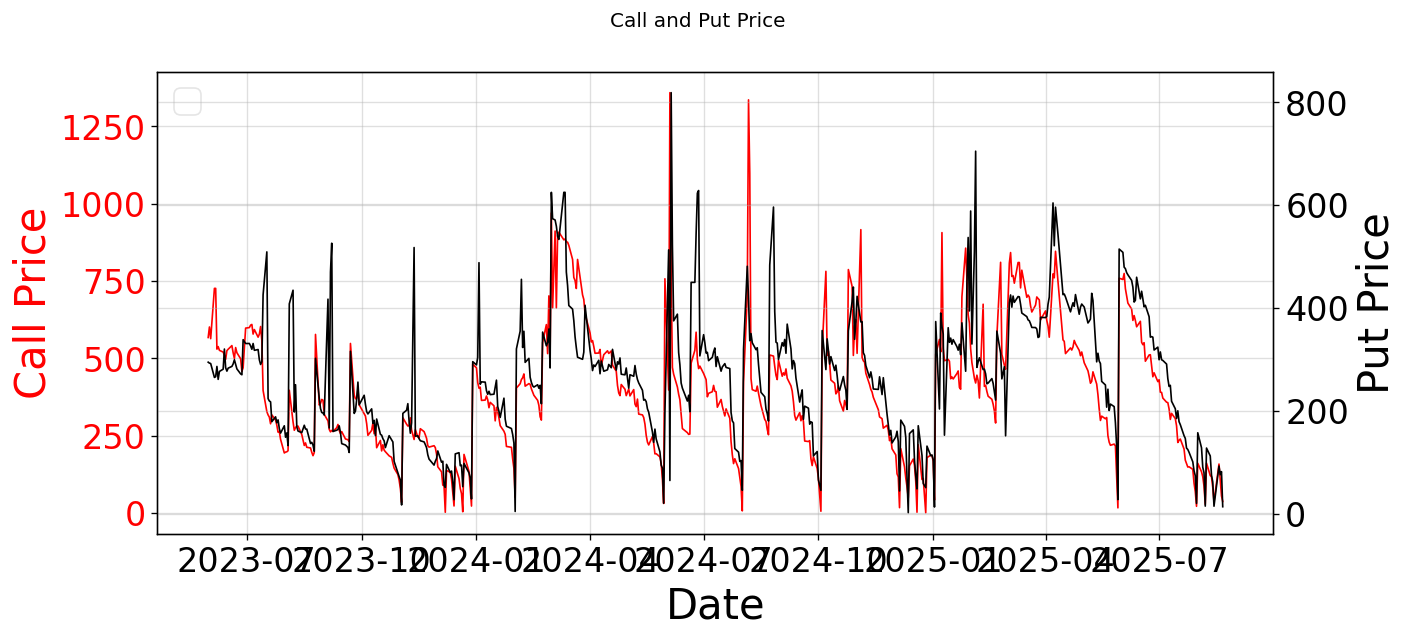

In [21]:
c = calls_atm.sort_values('Date')
p = puts_atm.sort_values('Date')

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(c['Date'],c['Close'], color = 'red')
ax1.set_ylabel("Call Price", color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(p['Date'],p['Close'], color = 'black')
ax2.set_ylabel("Put Price", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Handle legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

# Titles & legends
fig.suptitle("Call and Put Price")
ax1.set_xlabel("Date")

plt.show()

### Define some functions for calculations

In [22]:
plt.rcParams.update({
    # --- Figure & Layout ---
    'figure.figsize': (10, 5),         # default size for all plots
    'figure.dpi': 120,                 # resolution
    'figure.autolayout': True,         # prevent label cutoffs

    # --- Fonts & Text ---
    'font.size': 10,                   # base font size
    'axes.titlesize': 14,              # title font size
    'axes.labelsize': 12,              # x/y label size
    'xtick.labelsize': 8,              # x tick labels
    'ytick.labelsize': 8,              # y tick labels
    'legend.fontsize': 9,              # legend font size
    'font.family': 'serif',            # or 'sans-serif', 'monospace'

    # --- Axes & Grid ---
    'axes.spines.top': False,          # remove top spine for cleaner look
    'axes.spines.right': False,        # remove right spine
    'axes.grid': True,                 # enable grid by default
    'grid.linestyle': '--',
    'grid.alpha': 0.4,

    # --- Lines ---
    'lines.linewidth': 1.5,
    'lines.markersize': 4,

    # --- Legend ---
    'legend.loc': 'best',
    'legend.frameon': True,
    'legend.framealpha': 0.8,

    # --- Savefig defaults ---
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

### Determine implied interest rate

In [23]:
# implied interest rate from put call parity

def implied_rate(C, P, S, K, T):
    # k = r
    """
    Derive the implied interest rate from put-call parity.

    Parameters:
        C : float : Call option price
        P : float : Put option price
        S : float : Spot/Underlying price
        K : float : Strike price
        T : float : Time to maturity (in years)

    Returns:
        r : float : Implied risk-free interest rate
    """
    try:
        ratio = (S - (C - P)) / K
        if ratio <= 0:
            raise ValueError("Invalid input: log of non-positive number.")
        r = - (1 / T) * np.log(ratio)
        # k = r
        return r
    except Exception as e:
        # return f"Error: {e}"
        return 0


### Implied daily rates calculation from average of the put and call that are not na  

In [24]:
CE = df1[df1['Option type'] == 'CE']
PE = df1[df1['Option type'] == 'PE']

clms = ['Symbol', 'Date', 'Expiry', 'Option type', 'Strike Price', 'Open', 'High', 'Low', 'Close',
        'LTP', 'Settle Price','No. of contracts','Open Int', 'Change in OI', 'Underlying Value']
CE1 = CE[~CE['No. of contracts'].isna()][clms]
PE1 = PE[~PE['No. of contracts'].isna()][clms]

CE2 = CE1.groupby(['Symbol','Date','Expiry','Strike Price','Option type']).mean().reset_index()
PE2 = PE1.groupby(['Symbol','Date','Expiry','Strike Price','Option type']).mean().reset_index()

CE3 = CE2.merge(underlying_df1,on = 'Date' , how= 'left')
PE3 = PE2.merge(underlying_df1,on = 'Date' , how= 'left')

cl = ['Symbol', 'Date', 'Expiry', 'Option type', 'Strike Price', 'Close', 'NIFTY_Close']
pt = ['Date', 'Expiry', 'Option type', 'Strike Price', 'Close' ]

cl_ = ['Symbol', 'Date', 'Expiry', 'Call', 'Strike Price', 'Call_P', 'NIFTY_Close']
pt_ = ['Date', 'Expiry', 'Put', 'Strike Price', 'Put_P' ]

call_ = copy.deepcopy(CE3)[cl].dropna()
put_all_ = copy.deepcopy(PE3)[pt].dropna()

call_.columns = cl_
put_all_.columns = pt_

merged = call_.merge(put_all_, on= ['Date', 'Expiry','Strike Price'], how = 'left').dropna()

merged['rate'] = merged.apply(
    lambda row: implied_rate(
        C=row['Call_P'],
        P=row['Put_P'],
        S=row['NIFTY_Close'],
        K=row['Strike Price'],
        T=(row['Expiry'] - row['Date']).days / 365
    ),
    axis=1
)

rates_1 = merged[['Date','rate']].groupby('Date').mean().reset_index()

In [25]:
## OUTLIER SMOOTHING

def smooth_outliers(df, col='rate'):
    # Step 1: Calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - IQR
    upper = Q3 + IQR

    # Step 2: Identify outliers
    mask = (df[col] < lower) | (df[col] > upper)

    # Step 3: Replace outliers with average of prev and next value
    for idx in df[mask].index:
        prev_idx = idx - 1 if idx > 0 else None
        next_idx = idx + 1 if idx < len(df) - 1 else None

        if prev_idx is not None and next_idx is not None:
            df.at[idx, col] = (df.at[prev_idx, col] + df.at[next_idx, col]) / 2
        elif prev_idx is not None:  # if outlier at last row
            df.at[idx, col] = df.at[prev_idx, col]
        elif next_idx is not None:  # if outlier at first row
            df.at[idx, col] = df.at[next_idx, col]

    return df

### Smoothening IV twice by IQR for outlier removal

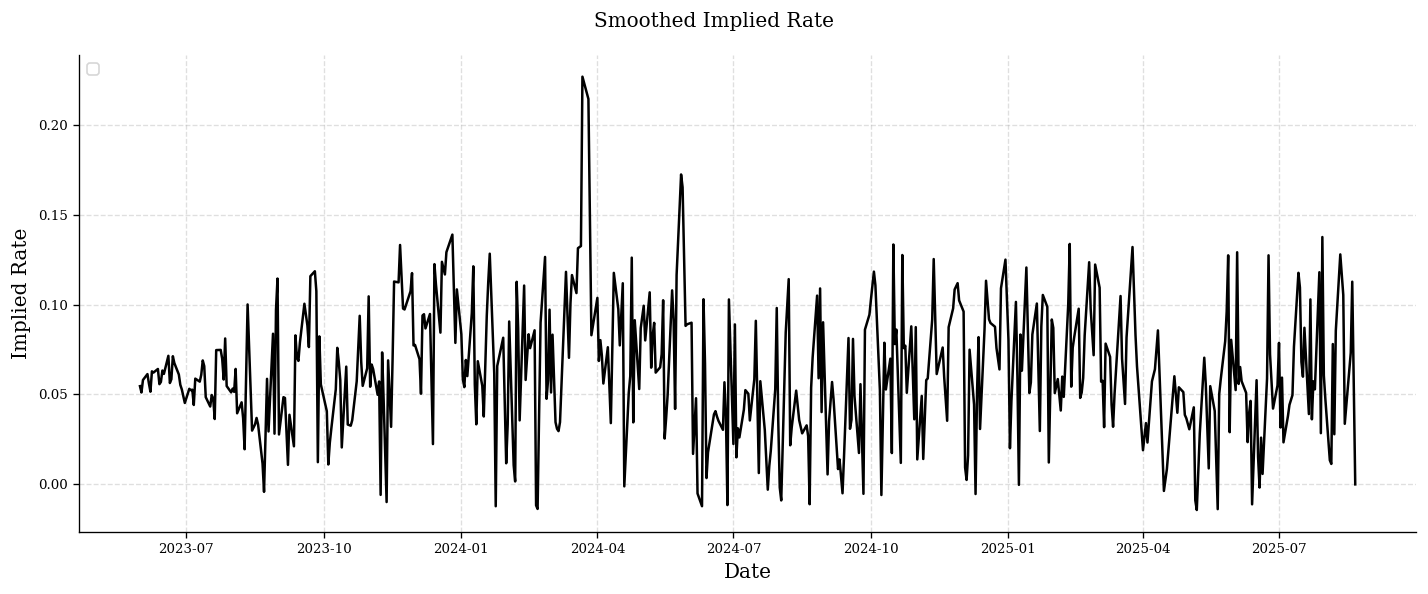

In [26]:
## Smoothened twice for Outliers on daily basis for a reasonable ness of interest rate
rates_use = smooth_outliers(rates_1, col='rate')
rates_use2 = smooth_outliers(rates_use, col='rate')

# rates_use2['rate'].plot()

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(rates_use2['Date'],rates_use2['rate'], color = 'black')
ax1.set_ylabel("Implied Rate", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Handle legends from both axes
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, loc="upper left")

# Titles & legends
fig.suptitle("Smoothed Implied Rate")
ax1.set_xlabel("Date")

plt.show()

In [27]:
# ir = rates_use2.set_index('Date')
# ir.to_excel(f'{parent_folder}//implied_rates.xlsx')

#### Calculate implied volatility by self defined function and quantlib

In [28]:

# Calculate implied volatility
def calculate_implied_volatility(
    option_price: float, S: float, K: float, T: float, r: float, option_type: str, moneyness: Optional[str] = None
) -> Optional[float]:
    """
    Calculate implied volatility using the Black-Scholes model.

    Args:
        option_price: Market price of the option
        S: Current stock price (underlying asset price)
        K: Strike price of the option
        T: Time to expiration in years
        r: Risk-free interest rate
        option_type: Type of option (ContractType.CALL or ContractType.PUT)

    Returns:
        Implied volatility as a float, or None if calculation fails
    """
    # Define a reasonable range for sigma
    sigma_lower = 1e-6
    sigma_upper = 1.0  # Adjust upper limit if necessary : Index not exepceted above 100%
    
    if T < 0:
        raise ValueError("Expiry must be after valuation date")
    elif T == 0:
        if moneyness == 'OTM':
            option_price = 0
        # T = 1/(252)

    # Check if the option is out-of-the-money and price is close to zero
    intrinsic_value = max(0, (S - K) if option_type == "call" else (K - S))
    if option_price <= intrinsic_value + 1e-6:
        # print("Option price is close to intrinsic value; implied volatility is near zero.") # Uncomment for checking the status
        return 0.0

    # Define the function to find the root
    def option_price_diff(sigma: float) -> float:
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        if option_type == "call":
            price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        elif option_type == "put":
            price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        return price - option_price

    try:
        return brentq(option_price_diff, sigma_lower, sigma_upper)
    except ValueError as e:
        # print(f"Failed to find implied volatility: {e}")
        return None

In [29]:

def calculate_implied_volatility_ql(
    option_price: float, S: float, K: float, T: float, r: float, option_type: str
) -> float:
    """
    Calculate implied volatility using QuantLib (no-dividend Black-Scholes model).
    """

    # Dates
    todays_date = ql.Date.todaysDate()
    ql.Settings.instance().evaluationDate = todays_date
    maturity_date = todays_date + int(T * 365)
    
    if T < 0:
        raise ValueError("Expiry must be after valuation date")
    elif T == 0:
        T = 1/(24*252)

    # Payoff
    payoff = ql.PlainVanillaPayoff(
        ql.Option.Call if option_type.lower() == "call" else ql.Option.Put, K
    )
    exercise = ql.EuropeanExercise(maturity_date)
    european_option = ql.VanillaOption(payoff, exercise)

    # Market data
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S))
    flat_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(todays_date, r, ql.Actual365Fixed())
    )
    vol_handle = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(todays_date, ql.NullCalendar(), 0.20, ql.Actual365Fixed())
    )

    # ✅ No-dividend Black-Scholes process
    bsm_process = ql.BlackScholesProcess(spot_handle, flat_ts, vol_handle)

    # Implied volatility
    try:
        iv = european_option.impliedVolatility(
            option_price,
            bsm_process,
            1e-6,   # accuracy
            1000,   # max iterations
            1e-6,   # min vol
            1.0     # max vol
        )
        return iv
    except RuntimeError:
        return None


### Calculate the implied  volatility for Calls 

In [30]:
calls_df1 = c.merge(rates_use2, on = 'Date')
puts_df1 = p.merge(rates_use2, on = 'Date')


calls_df1['IV'] = calls_df1.apply(
    lambda row: calculate_implied_volatility(
        option_price =row['Close'],
        S=row['NIFTY_Close'],
        K=row['Strike Price'],
        T=(row['Expiry'] - row['Date']).days / 365,
        r = row['rate'],
        option_type = 'call',
        moneyness= row['moneyness']
    ),
    axis=1
)

calls_df1['IV_QLIB'] = calls_df1.apply(
    lambda row: calculate_implied_volatility_ql(
        option_price =row['Close'],
        S=row['NIFTY_Close'],
        K=row['Strike Price'],
        T=(row['Expiry'] - row['Date']).days / 365,
        r = row['rate'],
        option_type = 'call'
    ),
    axis=1
)

<Axes: >

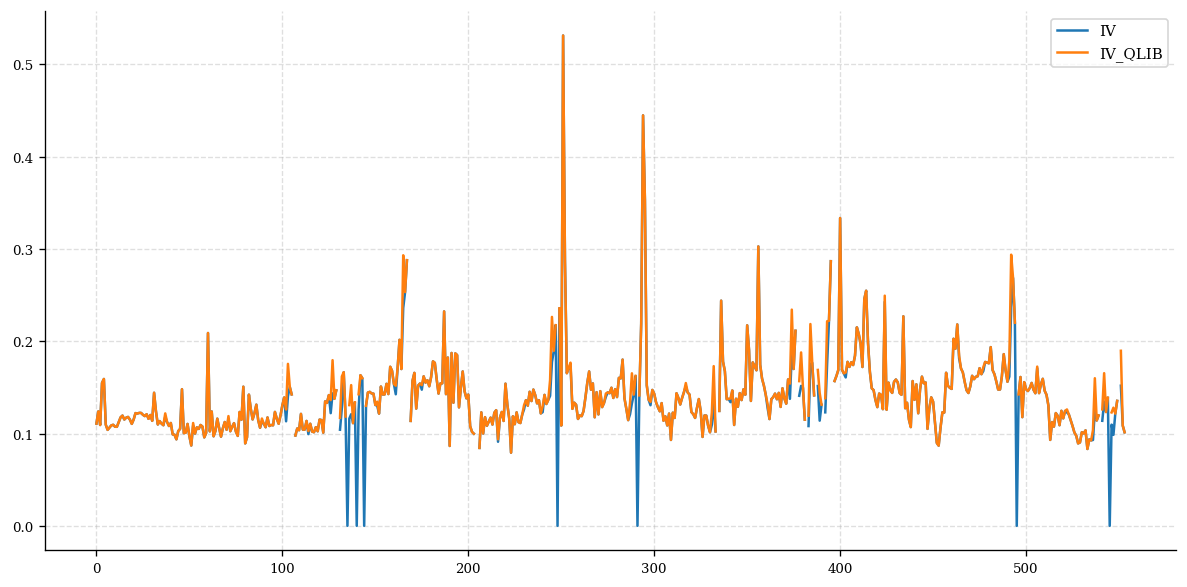

In [31]:
calls_df1[['IV','IV_QLIB']].plot()

In [32]:
puts_df1['IV'] = puts_df1.apply(
    lambda row: calculate_implied_volatility(
        option_price =row['Close'],
        S=row['NIFTY_Close'],
        K=row['Strike Price'],
        T=(row['Expiry'] - row['Date']).days / 365,
        r = row['rate'],
        option_type = 'put',
        moneyness= row['moneyness']
    ),
    axis=1
)

puts_df1['IV_QLIB'] = puts_df1.apply(
    lambda row: calculate_implied_volatility_ql(
        option_price =row['Close'],
        S=row['NIFTY_Close'],
        K=row['Strike Price'],
        T=(row['Expiry'] - row['Date']).days / 365,
        r = row['rate'],
        option_type = 'put'
    ),
    axis=1
)

<Axes: >

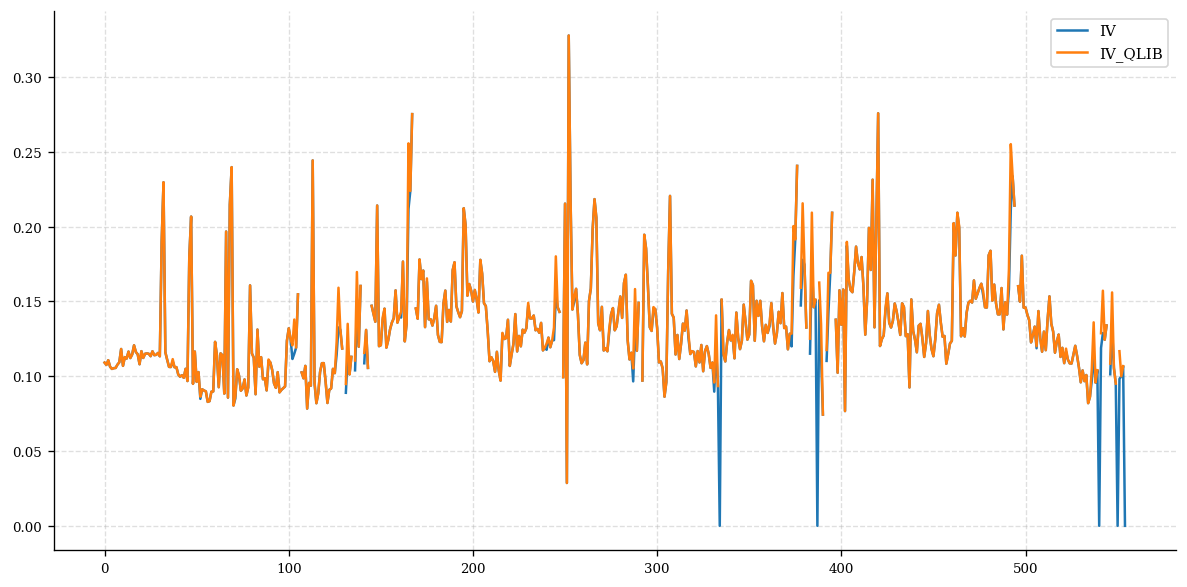

In [33]:
puts_df1[['IV','IV_QLIB']].plot()

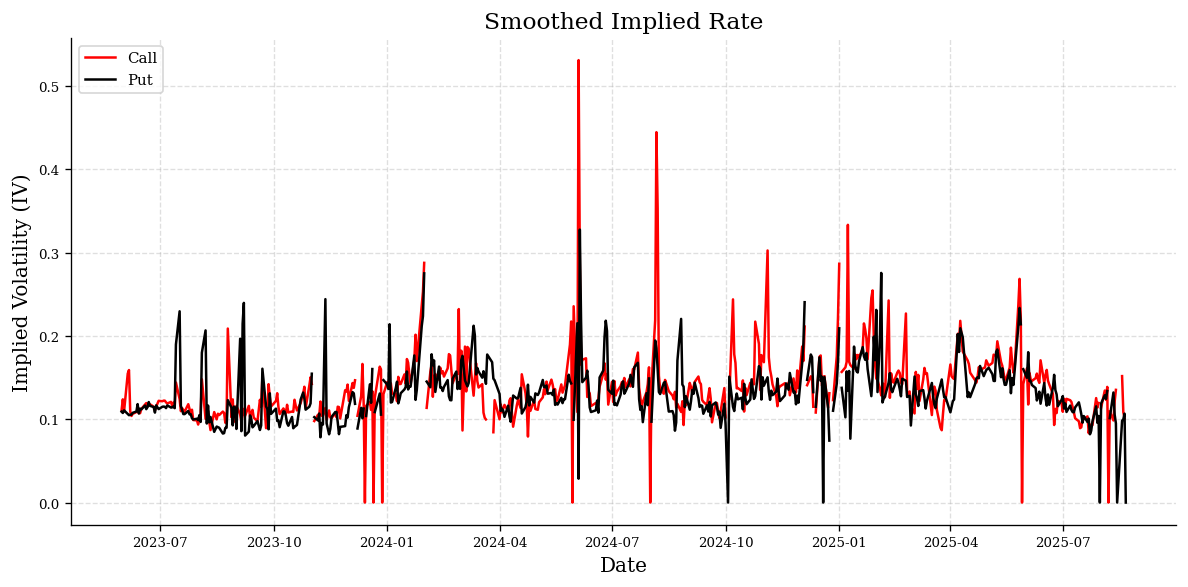

In [34]:
# calls_df1.IV.dropna().plot(color = 'red')
# plt.plot(calls_df1.Date, calls_df1.IV, color = 'red')
# plt.plot(puts_df1.Date, puts_df1.IV, color = 'black')

fig, ax = plt.subplots()

# Plot both series on the same axis
ax.plot(calls_df1['Date'], calls_df1['IV'], color='red', label='Call')
ax.plot(puts_df1['Date'], puts_df1['IV'], color='black', label='Put')

# Set labels and title
ax.set_ylabel("Implied Volatility (IV)")
ax.set_xlabel("Date")
ax.set_title("Smoothed Implied Rate")

# Add legend
ax.legend(loc="upper left")

# Customize appearance
ax.tick_params(axis='y')

plt.show()

### Taking average of call and Put IV to come to a acceptable IV which will be compared to the underlying for sanity

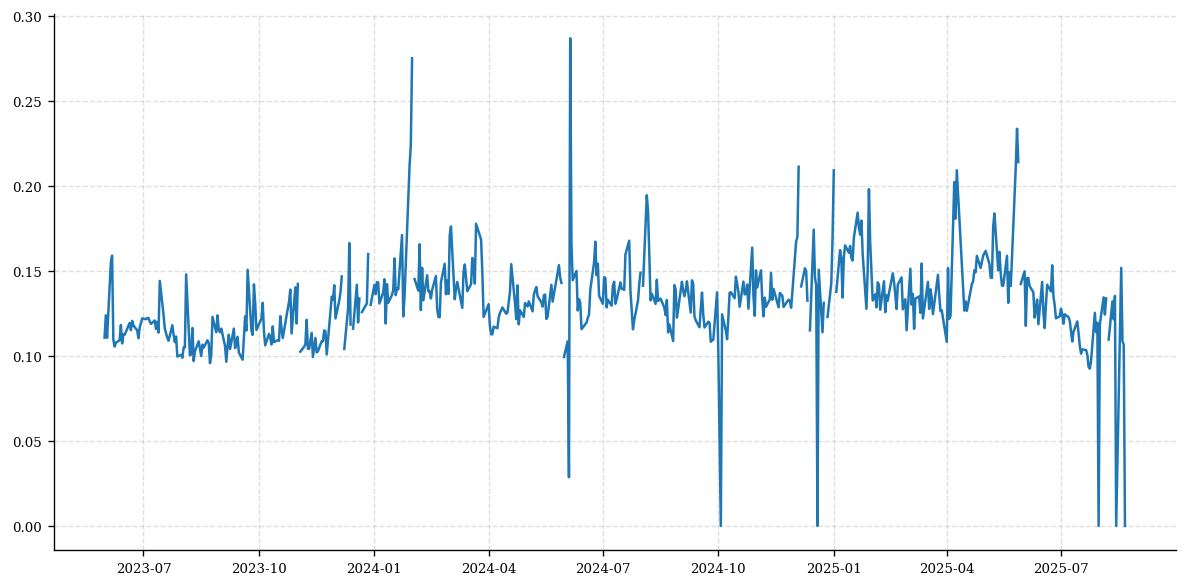

In [35]:
IV = calls_df1[['Date','IV']].merge(puts_df1[['Date','IV']], on = 'Date')
# IV['IV'] = (IV['IV_x'] + IV['IV_y'])/2
# IV['IV'] = IV[['IV_x', 'IV_y']].min(axis=1)

long_term_mean = IV[['IV_x', 'IV_y']].stack().mean()   # or your own constant / rolling mean

# compute absolute distance from long-term mean
dist_x = abs(IV['IV_x'] - long_term_mean)
dist_y = abs(IV['IV_y'] - long_term_mean)

# choose the IV closer to long-term mean
IV['IV'] = np.where(dist_x < dist_y, IV['IV_x'], IV['IV_y'])


plt.plot(IV.Date, IV.IV)

### USE GARMAN KLASS VOLATILITY FROM HISTORICAL DATA 

In [36]:
def garman_klass_volatility(df: pd.DataFrame) -> pd.Series:

    # Ensure required columns exist
    required_cols = {'Open', 'High', 'Low', 'Close'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain {required_cols}")

    log_hl = np.log(df['High'] / df['Low'])
    log_co = np.log(df['Close'] / df['Open'])

    variance = 0.5 * (log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
    volatility = np.sqrt(variance.clip(lower=0))  # avoid negative under sqrt

    ann_vol = volatility * np.sqrt(252)

    return ann_vol


In [37]:
df_vol1 =  underlying_df[['Date ','Open ', 'High ', 'Low ', 'Close ']]
df_vol1.columns = ['Date','Open', 'High', 'Low', 'Close']

df_vol1['Date'] = pd.to_datetime(df_vol1['Date'], errors= 'coerce')
df_vol2 = df_vol1.set_index('Date')
# df_vol2

### Parkinson Volatility

In [38]:
def parkinson_volatility(df: pd.DataFrame) -> pd.Series:
    """
    Compute daily Parkinson volatility from historical OHLC data.

    Args:
        df: DataFrame with columns ['High', 'Low']

    Returns:
        Pandas Series of daily volatilities
    """
    # Ensure required columns exist
    required_cols = {'High', 'Low'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain {required_cols}")
    log_hl = np.log(df['High'] / df['Low'])
    variance = (log_hl ** 2) / (4 * np.log(2))
    volatility = np.sqrt(variance)
    ann_vol = volatility * np.sqrt(252)

    return ann_vol

In [39]:

def agk_volatility(df: pd.DataFrame, Nobs: int) -> pd.Series:
    """
    Compute daily AGK (Adjusted Garman-Klass/Parkinson) volatility estimator.
    
    Reference: Modified Parkinson-Garman-Klass formula with small-sample corrections.
    
    Args:
        df: DataFrame with columns ['Open', 'High', 'Low', 'Close']
        Nobs: int, number of observations (e.g., number of intraday bars or sample days)
    
    Returns:
        Pandas Series of daily volatility (σ_agk)
    """
    required_cols = {'Open', 'High', 'Low', 'Close'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns {required_cols}")

    # Precompute log terms
    ln_HL = np.log(df['High'] / df['Low'])
    ln_HO = np.log(df['High'] / df['Open'])
    ln_LO = np.log(df['Low'] / df['Open'])
    ln_CO = np.log(df['Close'] / df['Open'])
    ln_HL_term = np.log(df['High'] * df['Low'] / (df['Open'] ** 2))

    # We'll iterate once since σ_agk appears on both sides (implicit formula)
    # Start with Parkinson estimate as initial guess
    sigma_parkinson = np.sqrt((ln_HL ** 2) / (4 * np.log(2)))
    sigma_agk_prev = sigma_parkinson.copy()

    # Iterate once or twice to refine σ_agk
    for _ in range(2):
        term1 = 0.511 * (
            (ln_HL ** 2)
            + (0.9079 / Nobs) * (sigma_agk_prev ** 2)
            + (1.8144 / np.sqrt(Nobs)) * ln_HL * sigma_agk_prev
        )

        term2 = 0.038 * (
            (ln_HO * ln_LO)
            - (0.2058 / Nobs) * (sigma_agk_prev ** 2)
            - (0.4536 / np.sqrt(Nobs)) * ln_HL * sigma_agk_prev
        )

        term3 = -0.019 * (ln_CO * ln_HL_term)
        term4 = -0.383 * (ln_CO ** 2)

        sigma2_agk = term1 + term2 + term3 + term4
        sigma_agk = np.sqrt(np.maximum(sigma2_agk, 0))
        sigma_agk_prev = sigma_agk  # update for next iteration
        

    return sigma_agk


### Rogers–Satchell (RS) volatility estimator

In [40]:
def rogers_satchell_volatility(df: pd.DataFrame) -> pd.Series:
    """
    Compute daily Rogers-Satchell volatility from historical OHLC data.

    Args:
        df: DataFrame with columns ['Open', 'High', 'Low', 'Close']

    Returns:
        Pandas Series of daily volatilities
    """
    required_cols = {'Open', 'High', 'Low', 'Close'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain {required_cols}")

    term1 = np.log(df['High'] / df['Close']) * np.log(df['High'] / df['Open'])
    term2 = np.log(df['Low'] / df['Close']) * np.log(df['Low'] / df['Open'])
    variance = term1 + term2
    volatility = np.sqrt(variance)
    ann_vol = volatility * np.sqrt(252)

    return ann_vol

In [41]:
vix_df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Prev. Close', 'Change','% Change', 'source_file']
vix_df['Date'] = pd.to_datetime(vix_df['Date'], errors= 'coerce')

vix_df2 =  vix_df[['Date','Open', 'High', 'Low', 'Close']].sort_values('Date')
vix_df3 = vix_df2.set_index('Date')

### Comparing the IV to the VIX for checking the suitability

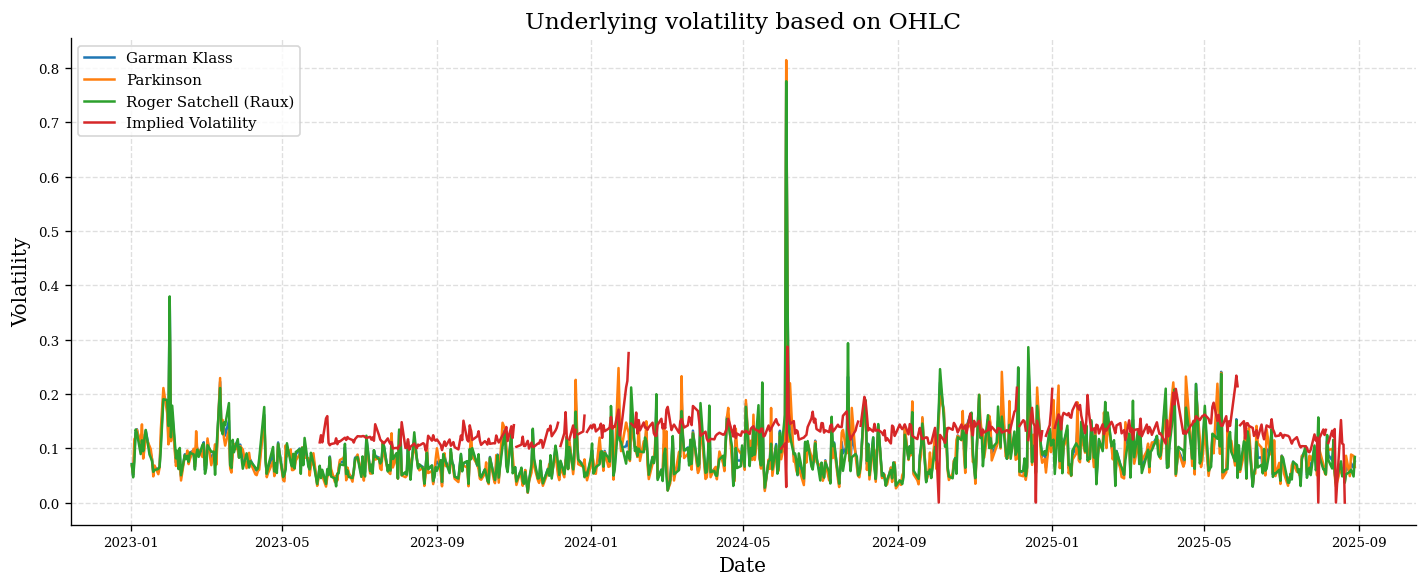

In [42]:
# (garman_klass_volatility(df = df_vol2)).plot()
# parkinson_volatility(df = df_vol2).plot()
# rogers_satchell_volatility(df = df_vol2).plot()

fig, ax = plt.subplots(figsize=(12, 5))

# Plot both series on the same axis
ax.plot(df_vol2.index, garman_klass_volatility(df = df_vol2), label='Garman Klass')
ax.plot(df_vol2.index, parkinson_volatility(df = df_vol2), label='Parkinson')
ax.plot(df_vol2.index, rogers_satchell_volatility(df = df_vol2), label='Roger Satchell (Raux)')
# plt.plot(IV.Date, IV.IV)
ax.plot(IV.Date, IV.IV, label='Implied Volatility')


# Set labels and title
ax.set_ylabel("Volatility")
ax.set_xlabel("Date")
ax.set_title("Underlying volatility based on OHLC")
ax.tick_params( labelsize=8)

# Add legend
ax.legend(loc="upper left")

# Customize appearance
ax.tick_params(axis='y')

plt.show()

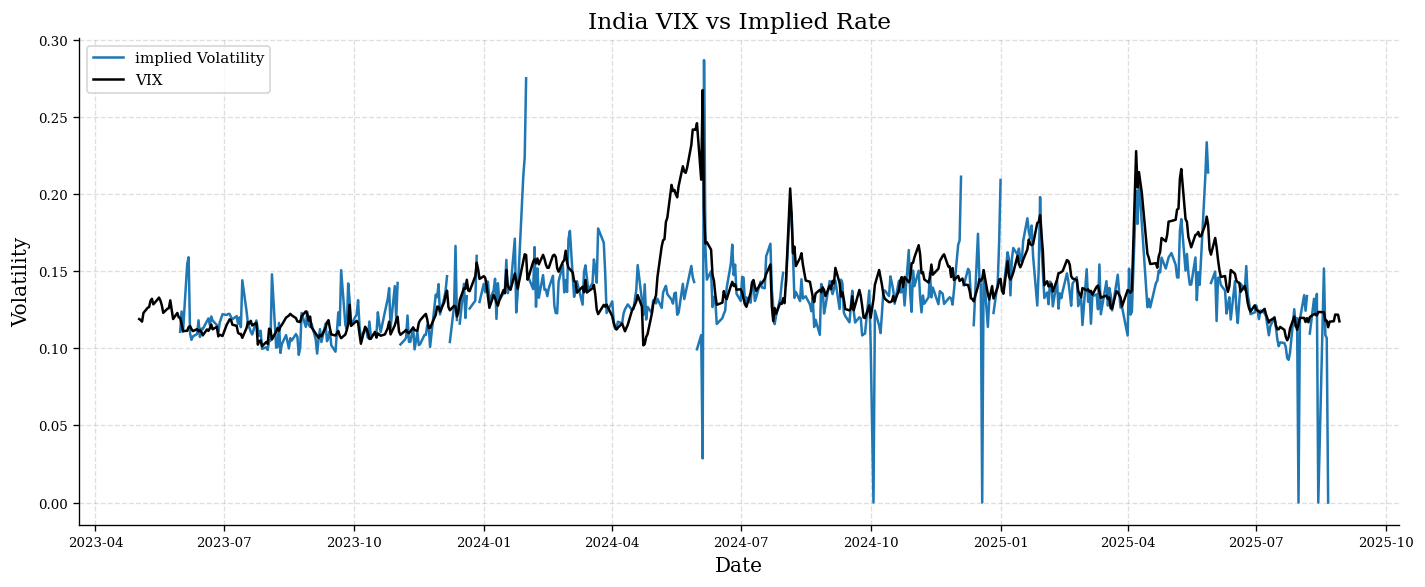

In [43]:
# plt.plot(IV.Date, IV.IV)
# (vix_df3['Close']/100).plot()


fig, ax = plt.subplots(figsize=(12, 5))

# Plot both series on the same axis
ax.plot(IV['Date'], IV['IV'], label='implied Volatility')
ax.plot(vix_df3.index, vix_df3['Close']/100, color='black', label='VIX')

# Set labels and title
ax.set_ylabel("Volatility")
ax.set_xlabel("Date")
ax.set_title("India VIX vs Implied Rate")

# Add legend
ax.legend(loc="upper left")

# Customize appearance
ax.tick_params(axis='y')
# ax.tick_params( labelsize=8)


plt.show()

##### The block below takes 17 Minute - the file is saved in cache and the block is commented for faster processing

In [44]:
#################################################################################################

In [ ]:

df_CE_IV = df_CE.copy()
df_CE = df_CE.merge(rates_1, on= 'Date')
df_CE['IV'] = df_CE.apply(
        lambda row: calculate_implied_volatility(
            option_price=row['Close'],
            S=row['NIFTY_Close'],
            K=row['Strike Price'],
            T=(row['Expiry'] - row['Date']).days / 365,
            r=row['rate'],
            option_type='call',
            moneyness= row['moneyness']
        ),
        axis=1
    )

df_CE['IV_QLIB'] = df_CE.apply(
        lambda row: calculate_implied_volatility_ql(
            option_price=row['Close'],
            S=row['NIFTY_Close'],
            K=row['Strike Price'],
            T=(row['Expiry'] - row['Date']).days / 365,
            r=row['rate'],
            option_type='call'
        ),
        axis=1
    )

df_PE_IV = df_PE.copy()
df_PE = df_PE.merge(rates_1, on= 'Date')
df_PE['IV'] = df_PE.apply(
        lambda row: calculate_implied_volatility(
            option_price=row['Close'],
            S=row['NIFTY_Close'],
            K=row['Strike Price'],
            T=(row['Expiry'] - row['Date']).days / 365,
            r=row['rate'],
            option_type='put',
            moneyness= row['moneyness']
        ),
        axis=1
    )


df_PE['IV_Qlib'] = df_PE.apply(
        lambda row: calculate_implied_volatility_ql(
            option_price=row['Close'],
            S=row['NIFTY_Close'],
            K=row['Strike Price'],
            T=(row['Expiry'] - row['Date']).days / 365,
            r=row['rate'],
            option_type='put'
        ),
        axis=1
    )

df_CE['T2E'] = (df_CE['Expiry'] - df_CE['Date'])
df_PE['T2E'] = (df_PE['Expiry'] - df_PE['Date'])

df_CE1 = copy.deepcopy(df_CE)
df_PE1 = copy.deepcopy(df_PE)

with open(f'{path}\\caches\\df_CE.pkl', 'wb') as file1:
    pickle.dump(df_CE, file1)

with open(f'{path}\\caches\\df_PE.pkl', 'wb') as file2:
    pickle.dump(df_PE, file2)


In [ ]:
# df_PE1[['IV','IV_Qlib']].dropna()#.plot()
# (df_PE1['IV'].dropna() - df_PE1['IV_Qlib'].dropna()).plot()

# df_PE1['IV'].plot()

##### - use the below block in lieu of the above to get the same results 

In [ ]:
# import pickle
# import numpy as np

# with open(f'{path}\\caches\\df_CE.pkl', 'rb') as file1:
#     df_CE = pickle.load(file1)

# with open(f'{path}\\caches\\df_PE.pkl', 'rb') as file2:
#     df_PE = pickle.load(file2)

# df_CE1 = copy.deepcopy(df_CE)
# df_PE1 = copy.deepcopy(df_PE)

### This above block calculate IV for all the data

In [57]:
# add value of ATM in the moneyness
map_on = ['Symbol', 'Date', 'Expiry', 'Option type', 'Strike Price', 'Close', 'NIFTY_Close', 'val', 'moneyness']
df_CE1 = df_CE1.merge(calls_atm, on = map_on, how = 'outer')

df_CE1.loc[df_CE1["ATM"] == 1, "moneyness"] = "ATM"
df_CE1 = df_CE1.drop(columns = ['ATM'])
df_CE1 = df_CE1.dropna(subset=["IV"]).reset_index(drop=True)

df_PE1 = df_PE1.merge(puts_atm, on = map_on, how = 'outer')
df_PE1.loc[df_PE1["ATM"] == 1, "moneyness"] = "ATM"
df_PE1 = df_PE1.drop(columns = ['ATM'])
df_PE1 = df_PE1.dropna(subset=["IV"]).reset_index(drop=True)

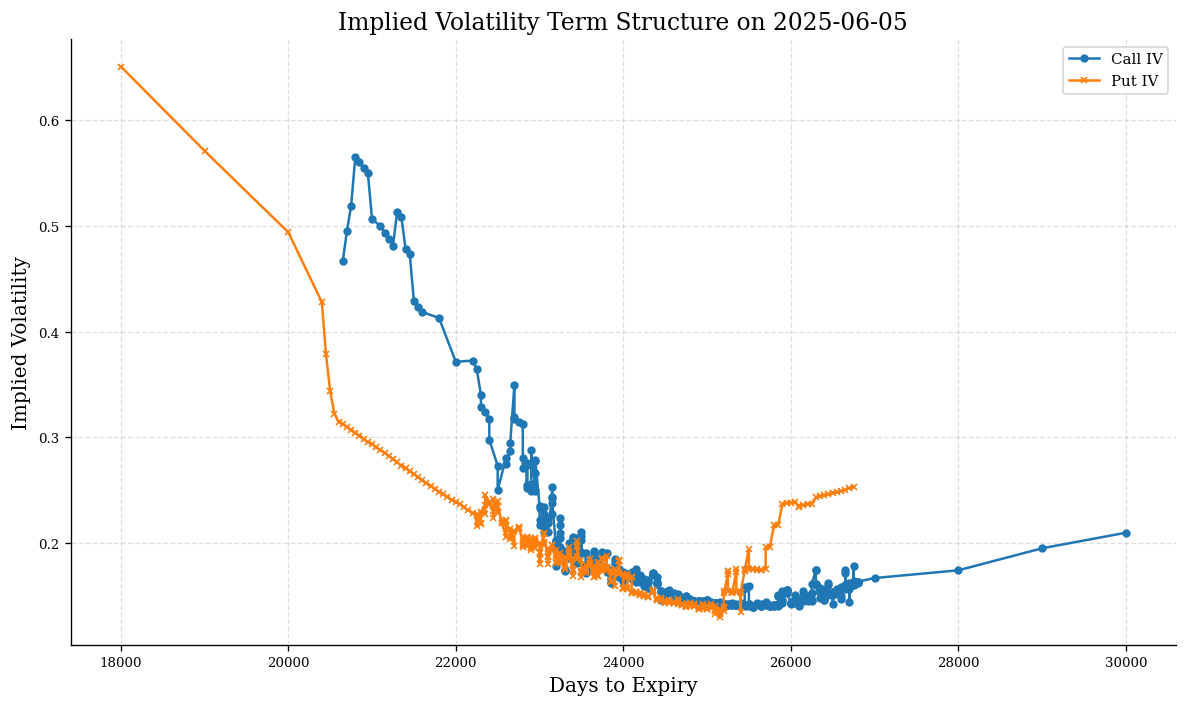

In [58]:
import datetime as dt

strikes = df_CE1['Strike Price'].unique()
Dates = df_CE1['Date'].unique()

i=500

x1 = df_CE1[df_CE1['Date'] == Dates[i]]
y1 = df_PE1[df_PE1['Date'] == x1['Date'].unique()[0]]

xx1 = x1.set_index('Strike Price')[['IV', 'moneyness']].sort_index()
yy1 = y1.set_index('Strike Price')[['IV', 'moneyness']].sort_index()

# xx1[xx1['IV'] != 0.0].plot()
xx2 = xx1[xx1['IV'] != 0.0]
yy2 = yy1[yy1['IV'] != 0.0]

#smoothened volatiilty curve
vol_curve = xx2['IV'].rolling(window = 5).mean().dropna()
vol_curve2 = yy2['IV'].rolling(window = 5).mean().dropna()

plt.figure(figsize=(10,6))
plt.plot(vol_curve.index, vol_curve, marker='o', linestyle='-')
plt.plot(vol_curve2.index, vol_curve2, marker='x', linestyle='-')


plt.title(f"Implied Volatility Term Structure on {str(Dates[i].date())}")
plt.xlabel("Days to Expiry")
plt.ylabel("Implied Volatility")
plt.legend(['Call IV', 'Put IV'])
plt.grid(True)
plt.show()

In [59]:
option_curve_CE = {}
option_curve_PE= {}
Dates_days = df_CE1['Date'].unique()
Dates_days_PE = df_PE1['Date'].unique()


i = j = 0
for dts in Dates_days:
    i+=1
    x1 = df_CE1[df_CE1['Date'] == dts]
    xx1 = x1.set_index('Strike Price')[['IV', 'moneyness']].sort_index()
    xx2 = xx1[xx1['IV'] != 0.0]
    vol_curve_CE = xx2['IV'].rolling(window = 5).mean().dropna()
    dt = str(dts.date())
    option_curve_CE[dt] = vol_curve_CE
    
for dts in Dates_days_PE:
    y1 = df_PE1[df_PE1['Date'] == dts]
    yy1 = y1.set_index('Strike Price')[['IV', 'moneyness']].sort_index()
    yy2 = yy1[yy1['IV'] != 0.0]
    vol_curve_PE = yy2['IV'].rolling(window = 5).mean().dropna()
    dt = str(dts.date())
    option_curve_PE[dt] = vol_curve_PE


In [60]:
def option_surface_plot(df, figsize=(8,6)):
    df['exp'] = df['T2E'].dt.days
    strikes = np.sort(df.index.unique())  
    maturities = np.sort(df.exp.unique())  
    
    # creating a meshgrid for strikes and maturities, essential for 3D plotting
    X, Y = np.meshgrid(strikes, maturities)  
    
    vol = np.empty([len(maturities), len(strikes)])  
    
    # looping through each maturity to interpolate option prices
    for i in range(len(maturities)):  
        s = df[df.exp == maturities[i]].index
        IV = df[df.exp == maturities[i]]['IV']  
        # using linear interpolation to estimate option IV for all strikes
        # f = interpolate.interp1d(s, IV, kind='linear', bounds_error=False, fill_value="extrapolate")  
        # storing interpolated IV values in the vol matrix
        # vol[i, :] = f(strikes)  
        vol[i, :] = IV.reindex(strikes, method='nearest', fill_value=np.nan).values

    # creating a new figure to plot the surface
    fig = plt.figure(figsize = figsize)
    
    ax = fig.add_subplot(111, projection='3d',alpha=0.5)
    ax.plot_surface(X, Y, vol, cmap=cm.coolwarm)
    tick_fontsize =8
    ax.set_ylabel('Maturity (days)', fontsize=tick_fontsize) 
    ax.set_xlabel('Strike', fontsize=tick_fontsize) 
    ax.set_zlabel('C(K, T)', fontsize=tick_fontsize)
    ax.set_title('Option Surface' , fontsize=tick_fontsize+2)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.tick_params(axis='z', labelsize=tick_fontsize)

    return fig, vol


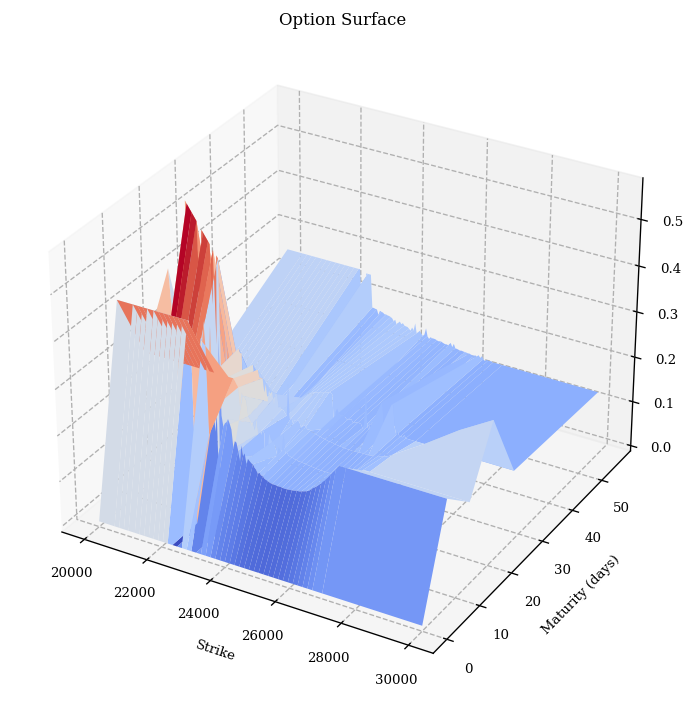

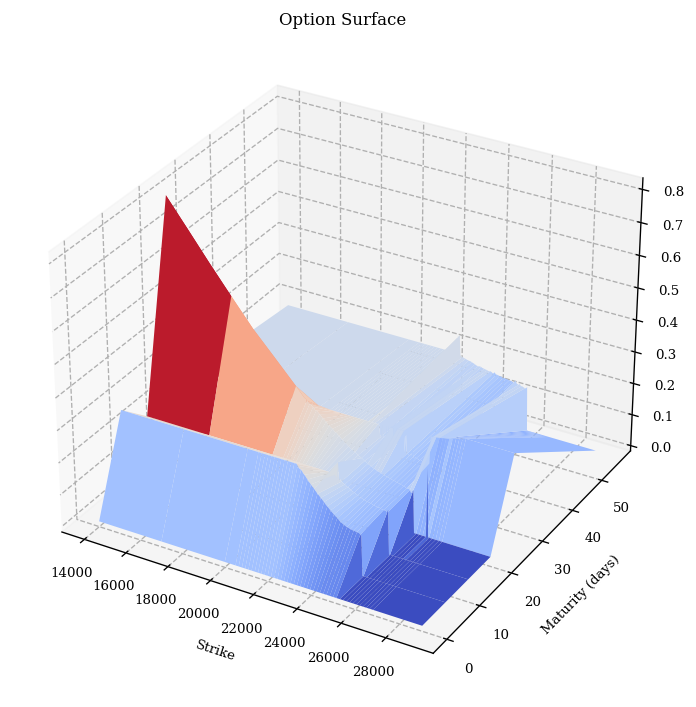

In [61]:
strikes = df_CE1['Strike Price'].unique()
Dates = df_CE1['Date'].unique()

i=500

x1 = df_CE1[df_CE1['Date'] == Dates[i]]
y1 = df_PE1[df_PE1['Date'] == x1['Date'].unique()[0]]

xx1 = x1.set_index('Strike Price')[['IV', 'moneyness','T2E']].sort_index()
yy1 = y1.set_index('Strike Price')[['IV', 'moneyness','T2E']].sort_index()


fig, vol = option_surface_plot(xx1)
fig, vol = option_surface_plot(yy1)

In [62]:
# a = list(option_curve_PE.keys())[500]
# # option_curve_PE[a].plot()
# option_curve_CE[a]#.plot()

<Axes: xlabel='Strike Price'>

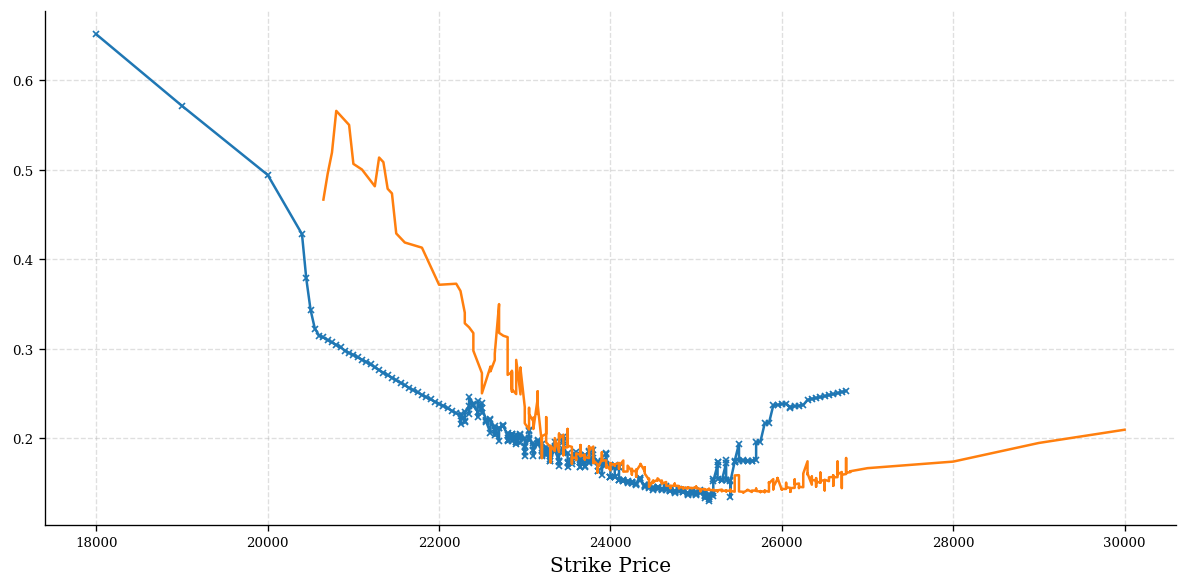

In [63]:
a = list(option_curve_PE.keys())[500]
option_curve_PE[a].plot( marker='x')
option_curve_CE[a].plot()


### Variable check point

In [ ]:
#############################################################################################

In [ ]:
# with open(f'{path}//caches//underlying_df1.pkl', 'wb') as file:
#     pickle.dump(underlying_df1, file)

# with open(f'{path}//caches//vix_df.pkl', 'wb') as file:
#     pickle.dump(vix_df, file)

# with open(f'{path}//caches//merged_df.pkl', 'wb') as file:
#     pickle.dump(merged_df, file)

# with open(f'{path}//caches//c.pkl', 'wb') as file:
#     pickle.dump(c, file)

# with open(f'{path}//caches//p.pkl', 'wb') as file:
#     pickle.dump(p, file)

# with open(f'{path}//caches//CE.pkl', 'wb') as file:
#     pickle.dump(CE, file)

# with open(f'{path}//caches//PE.pkl', 'wb') as file:
#     pickle.dump(PE, file)

# with open(f'{path}//caches//rates_1.pkl', 'wb') as file:
#     pickle.dump(rates_1, file)

# with open(f'{path}//caches//option_curve_CE.pkl', 'wb') as file:
#     pickle.dump(option_curve_CE, file)

# with open(f'{path}//caches//option_curve_PE.pkl', 'wb') as file:
#     pickle.dump(option_curve_PE, file)

# with open(f'{path}//caches//df_CE1.pkl', 'wb') as file:
#     pickle.dump(df_CE1, file)

# with open(f'{path}//caches//df_PE1.pkl', 'wb') as file:
#     pickle.dump(df_PE1, file)

# with open(f'{path}//caches//calls_atm.pkl', 'wb') as file:
#     pickle.dump(calls_atm, file)

# with open(f'{path}//caches//puts_atm.pkl', 'wb') as file:
#     pickle.dump(puts_atm, file)

In [64]:
# with open(f'{path}//caches//underlying_df1.pkl', 'rb') as file:
#     underlying_df1 = pickle.load(file)

# with open(f'{path}//caches//vix_df.pkl', 'rb') as file:
#     vix_df = pickle.load(file)

# with open(f'{path}//caches//merged_df.pkl', 'rb') as file:
#     merged_df = pickle.load(file)

# with open(f'{path}//caches//c.pkl', 'rb') as file:
#     c = pickle.load(file)

# with open(f'{path}//caches//p.pkl', 'rb') as file:
#     p = pickle.load(file)

# with open(f'{path}//caches//CE.pkl', 'rb') as file:
#     CE = pickle.load(file)

# with open(f'{path}//caches//PE.pkl', 'rb') as file:
#     PE = pickle.load(file)

# with open(f'{path}//caches//rates_1.pkl', 'rb') as file:
#     rates_1 = pickle.load(file)

# with open(f'{path}//caches//option_curve_CE.pkl', 'rb') as file:
#     option_curve_CE = pickle.load(file)

# with open(f'{path}//caches//option_curve_PE.pkl', 'rb') as file:
#     option_curve_PE = pickle.load(file)

# with open(f'{path}//caches//df_CE1.pkl', 'rb') as file:
#     df_CE1 = pickle.load(file)

# with open(f'{path}//caches//df_PE1.pkl', 'rb') as file:
#     df_PE1 = pickle.load(file)

# with open(f'{path}//caches//calls_atm.pkl', 'rb') as file:
#     calls_atm = pickle.load(file)

# with open(f'{path}//caches//puts_atm.pkl', 'rb') as file:
#     puts_atm = pickle.load(file)

### PLot IV surface

In [65]:

records = []
for date, strike_iv in option_curve_CE.items():
    for strike, iv in strike_iv.items():
        records.append({"Date": date, "Strike": strike, "IV": iv})

# Convert to DataFrame
df = pd.DataFrame(records)

# Pivot into a grid: rows = dates, cols = strikes
iv_matrix = df.pivot_table(index="Date", columns="Strike", values="IV", aggfunc="mean")

iv_matrix_filtered = iv_matrix.dropna(axis=1, thresh=len(iv_matrix) * 0.4)


In [66]:

def plot_iv_surface_numeric_y(vol_grid, max_dates=50, max_strikes=50):
  

    # Subsample if too large
    if len(vol_grid.index) > max_dates:
        vol_grid = vol_grid.iloc[::len(vol_grid.index)//max_dates, :]
    if len(vol_grid.columns) > max_strikes:
        vol_grid = vol_grid.iloc[:, ::len(vol_grid.columns)//max_strikes]

    # Convert dates to numeric: days-to-expiry from first date
    y_numeric = (pd.to_datetime(vol_grid.index) - pd.to_datetime(vol_grid.index[0])).days
    Y = y_numeric.values
    X = vol_grid.columns.astype(float).values
    Z = vol_grid.values.astype(float)

    # Mask NaNs
    Z = np.ma.masked_invalid(Z)

    # Create surface plot
    fig = go.Figure(data=[go.Surface(
        z=Z, x=X, y=Y, colorscale='Viridis', 
        cmin=np.nanmin(Z), cmax=np.nanmax(Z),
        showscale=True, 
        lighting=dict(ambient=0.7, diffuse=1, specular=0.5, roughness=0.5),
        lightposition=dict(x=100, y=200, z=0)
    )])

    # Update layout to make surface prominent
    fig.update_layout(
        title='IV Surface',
        scene=dict(
            xaxis_title='Strike Price',
            yaxis_title='Days to Expiry',
            zaxis_title='Implied Volatility',
            xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
            yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
            zaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        ),
        autosize=True
    )

    fig.show()


In [67]:
plot_iv_surface_numeric_y(vol_grid = iv_matrix_filtered.iloc[-100:,:].dropna(axis=1, thresh=10 * 0.6))

### Variance Swap

In [68]:
option_df = pd.concat([df_CE1.dropna(), df_PE1.dropna().rename(columns = {'IV_Qlib':'IV_QLIB'})], axis =0)

option_df['T2E_days'] = option_df['T2E'].dt.days
option_df['T2E_years'] = option_df['T2E_days'] / 365.0

# Ensure rate is float
option_df['rate'] = option_df['rate'].astype(float)

tenors = {'1W': 7, '2W': 14, '1M': 30, '3M': 90}

def variance_swap_strike(df):
    """
    Compute model-free fair variance strike (K_R^2) for a given expiry
    using discrete approximation of the variance swap replication formula.
    """
    if df.empty:
        return np.nan

    # Get time to expiry and mean risk-free rate for this expiry
    T = df['T2E_years'].iloc[0]
    r = df['rate'].mean()

    # Compute forward price using spot and mean rate
    S0 = df['NIFTY_Close'].iloc[0]
    F = S0 * np.exp(r * T)

    # Separate OTM puts and calls
    puts = df[(df['Option type'] == 'PE') & (df['Strike Price'] <= F)].copy()
    calls = df[(df['Option type'] == 'CE') & (df['Strike Price'] >= F)].copy()

    # Sort by strike
    puts.sort_values('Strike Price', inplace=True)
    calls.sort_values('Strike Price', inplace=True)

    # Compute ΔK for each
    puts['ΔK'] = puts['Strike Price'].diff().bfill()#fillna(puts['Strike Price'].iloc[1] - puts['Strike Price'].iloc[0])
    calls['ΔK'] = calls['Strike Price'].diff().bfill()#fillna(calls['Strike Price'].iloc[1] - calls['Strike Price'].iloc[0])

    # Apply discrete summation
    term_puts = (puts['ΔK'] / (puts['Strike Price']**2)) * np.exp(r * T) * puts['Close']
    term_calls = (calls['ΔK'] / (calls['Strike Price']**2)) * np.exp(r * T) * calls['Close']

    KR2 = (2 / T) * (term_puts.sum() + term_calls.sum())
    return KR2


In [69]:
# Compute time series
records = []
i = 0
tenors = {'1W': 7, '2W': 14, '1M': 30, '3M': 90}
for date, subdf in option_df.groupby('Date'):
    if len(subdf['T2E_days'].unique()) <= 3 and i ==0: continue
    else: i =1
    # print(subdf['T2E_days'].unique())
    for label, tenor in tenors.items():
        # pick nearest expiry matching target tenor
        near_expiries = subdf[np.abs(subdf['T2E_days'] - tenor) <= 3]  # ±3 day tolerance
        # i+=1
        # if i ==1:break
        if len(near_expiries) > 0:
            K_var = variance_swap_strike(near_expiries)
            records.append({'Date': date, 'Tenor': label, 'VarianceSwap': K_var})
            # records.append([date, label,  K_var])
            

In [70]:
varswap = pd.DataFrame(records).pivot_table(
    index= 'Date',
    columns= 'Tenor',
    values='VarianceSwap'
)
varswap_use = varswap[['1M','2W']].dropna()

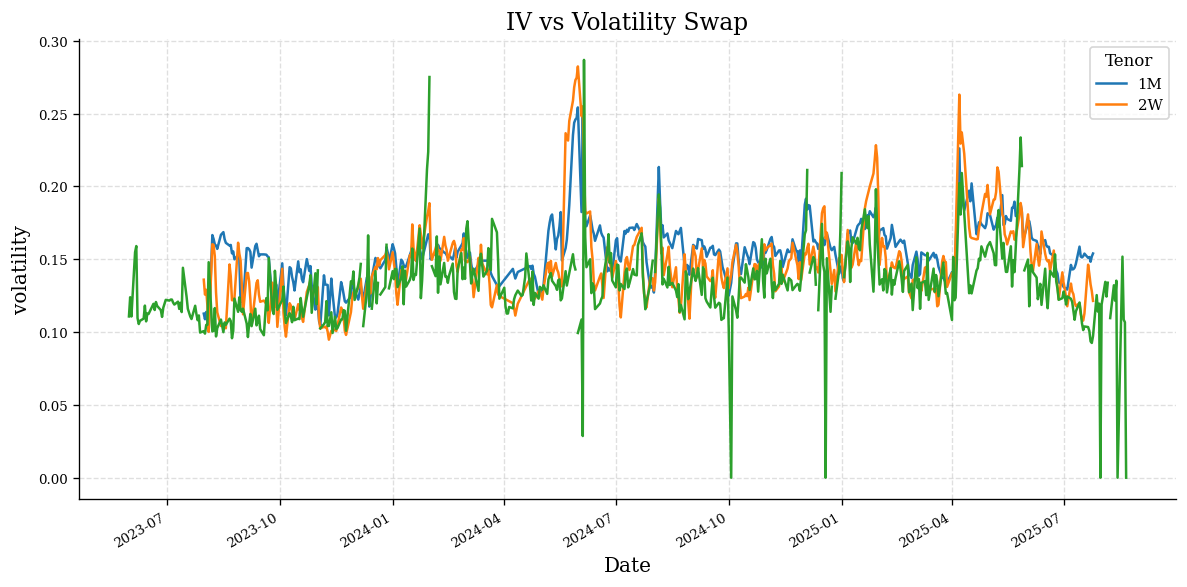

In [71]:
# np.sqrt(varswap).dropna().plot()
np.sqrt(varswap_use).plot()
IV.set_index('Date')['IV'].plot()
plt.title('IV vs Volatility Swap')
plt.ylabel('volatility')

plt.show()

In [72]:
merged_vswap = varswap_use.merge(IV.set_index('Date')[['IV']]**2, left_index=True, right_index=True, how='left')

In [73]:
sample_df1 = varswap_use.merge(df_CE1[['Date','NIFTY_Close']].groupby('Date').first().reset_index().set_index('Date').rename(columns = {'NIFTY_Close':'spot'}), left_index=True, right_index=True, how = 'left')
spot_series = pd.Series(sample_df1['spot'], index = sample_df1.index).astype(float)

In [74]:
vol_garman = pd.DataFrame(garman_klass_volatility(df = df_vol2), columns=['vol'])
vol_simple = pd.DataFrame(np.sqrt(np.log(df_vol2['Close']).diff().bfill()**2)).rename(columns = {'Close':'vol'})
# sample_df2 = varswap_use.merge(vol_garman, left_index=True, right_index=True, how = 'left')
sample_df2 = varswap_use.merge(vol_simple, left_index=True, right_index=True, how = 'left')

vol_series = pd.Series(sample_df2['vol'], index = sample_df2.index).astype(float)

### HESTON

In [75]:
DaysPerYear = 252  # trading days convention

# ------------------ helpers ------------------

def _safe_std(x: np.ndarray) -> float:
    x = x[~np.isnan(x)]
    return float(np.std(x, ddof=1)) if x.size > 1 else 0.0


def straight_line_regression(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    """Return intercept, slope using OLS (sklearn). Safe for NaNs and short arrays."""
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float)

    mask = (~np.isnan(x[:, 0])) & (~np.isnan(y))
    if mask.sum() < 2:
        return 0.0, 1.0  # fallback

    model = LinearRegression().fit(x[mask], y[mask])
    return float(model.intercept_), float(model.coef_[0])

# ------------------ calibrations ------------------

# def calibrate_kappa_from_varswap_returns(varswap_returns: dict,
#                                          short_tenor_months: int,
#                                          long_tenor_months: int) -> float:
def calibrate_kappa_from_varswap_returns(varswap: pd.DataFrame,
                                         short_tenor_months: str,
                                         long_tenor_months: str) -> float:
    # x = np.array(varswap_returns.get(short_tenor_months, []), dtype=float)
    # y = np.array(varswap_returns.get(long_tenor_months, []), dtype=float)
    varswap_returns = varswap.diff().ffill()
    x = np.array(varswap_returns[short_tenor_months], dtype=float)
    y = np.array(varswap_returns[long_tenor_months], dtype=float)

    mask = (~np.isnan(x)) & (~np.isnan(y))
    if mask.sum() < 2:
        return 1.0

    _, slope = straight_line_regression(x[mask], y[mask])

    # short = short_tenor_months / 12.0
    # long = long_tenor_months / 12.0
    short = 0.5/12
    long = 1/12

    denom = (long - short * slope)
    if abs(denom) < 1e-12:
        return 1.0
    kappa = (2.0 * (1.0 - slope)) / denom
    return float(kappa)


def instantaneous_variance_from_short_varswap(short_varswap: pd.Series,
                                              kappa: float,
                                              theta: float,
                                              short_tenor_months: int) -> pd.Series:
# def instantaneous_variance_from_short_varswap(varswap: pd.DataFrame,
#                                               kappa: float,
#                                               theta: float,
#                                               col_name: str) -> pd.Series:
    if short_varswap.empty:
        raise ValueError("short_varswap series is empty")

    tau = short_tenor_months / 12.0
    denom = (1.0 - math.exp(-kappa * tau))
    factor = (kappa * tau) / denom if denom != 0 else 1.0

    inst_vals = factor * short_varswap.values.astype(float) - kappa * theta * tau
    inst_vals = np.where(inst_vals > 1e-12, inst_vals, 0.0)
    return pd.Series(inst_vals, index=short_varswap.index).astype(float)

    # return pd.Series(varswap[col_name], index=varswap.index).astype(float)


def compute_returns(series: pd.Series, returns_type: str = "absolute", lag: int = 1) -> pd.Series:
    if returns_type == "absolute":
        return series.diff(periods=lag)
    elif returns_type == "log":
        return np.log(series).diff(periods=lag)
    elif returns_type == "relative_simple":
        return series.pct_change(periods=lag)
    else:
        raise ValueError("unsupported returns_type")


def calibrate_eta(instantaneous_variance: pd.Series,
                  kappa: float,
                  theta: float,
                  delta_days: int) -> Tuple[float, np.ndarray]:
    v = instantaneous_variance.values.astype(float)
    delta_t = delta_days / float(DaysPerYear)

    dz = []
    min_vi = np.nanmin(np.abs(v[v > 0]))
    for i in range(len(v) - 1):
        dv = v[i+1] - v[i]
        drift = kappa * (theta - v[i]) * delta_t
        # denom = np.sqrt(max(v[i], 1e-12) * delta_t)
        denom = np.sqrt(max(v[i], min_vi) * delta_t)
        
        dz_val = (dv - drift) / denom
        dz.append(dz_val)

    dz = np.array(dz)
    sigma = _safe_std(dz)
    eta = float(sigma)
    normalized = dz / sigma if sigma > 0 else np.full_like(dz, np.nan)
    return eta, normalized


# def calibrate_rho(spot_series: pd.Series,
#                   instantaneous_variance: pd.Series,
#                   normalized_dz: np.ndarray,
#                   delta_days: int) -> float:
#     d_w = compute_returns(spot_series, returns_type="log", lag=delta_days).values

#     min_len = min(len(d_w), len(normalized_dz))
#     if min_len <= 0:
#         return 0.0

#     arr_w = d_w[-min_len:]
#     arr_z = normalized_dz[-min_len:]
#     mask = (~np.isnan(arr_w)) & (~np.isnan(arr_z))
#     if mask.sum() < 2:
#         return 0.0

#     rho = float(np.corrcoef(arr_w[mask], arr_z[mask])[0, 1])
#     if math.isnan(rho):
#         return 0.0
#     return max(min(rho, 1.0), -1.0)
def calibrate_rho(spot_series: pd.Series,
                  instantaneous_variance: pd.Series,
                  normalized_dz: np.ndarray,
                  delta_days: int) -> float:
    # instantaneous_variance = pd.Series(instantaneous_variance, index = normalized_dz.index).astype(float)
    # normalized_dz = pd.Series(normalized_dz, index = instantaneous_variance.index).astype(float)
    
    # d_w = vol_series.values[:len(instantaneous_variance)]/ np.sqrt(instantaneous_variance * delta_days)
    d_w = np.log(spot_series[:len(instantaneous_variance)]).diff().bfill()/ np.sqrt(instantaneous_variance * delta_days)
    

    min_len = min(len(d_w), len(normalized_dz))
    if min_len <= 0:
        return 0.0

    arr_w = d_w[-min_len:]
    arr_z = normalized_dz[-min_len:]
    mask = (~np.isnan(arr_w)) & (~np.isnan(arr_z))
    if mask.sum() < 2:
        return 0.0
    rho = float(np.corrcoef(arr_w[mask], arr_z[mask])[0, 1])
    if math.isnan(rho):
        return 0.0
    return max(min(rho, 1.0), -1.0)


# ------------------ main pipeline ------------------

# def get_heston_parameters_from_varswaps(spot_series: pd.Series,
#                                         short_varswap: pd.Series,
#                                         long_varswap: pd.Series,
#                                         varswap_returns_by_tenor: dict,
#                                         short_tenor_months: int,
#                                         long_tenor_months: int,
#                                         delta_days: int) -> dict:
def get_heston_parameters_from_varswaps(spot_series: pd.Series,
                                        varswap: pd.DataFrame,
                                        short_tenor_months: str,
                                        long_tenor_months: str,
                                        delta_days: int) -> dict:
    short_varswap = pd.Series(varswap[short_tenor_months], index=varswap.index).astype(float)
    long_varswap = pd.Series(varswap[long_tenor_months], index=varswap.index).astype(float)
    
    # 1) mean reversion speed
    # kappa = calibrate_kappa_from_varswap_returns(varswap_returns_by_tenor,
    #                                              short_tenor_months,
    #                                              long_tenor_months)
    kappa = calibrate_kappa_from_varswap_returns(varswap,
                                                 short_tenor_months,
                                                 long_tenor_months)

    # 2) long-run variance level
    theta = float(np.nanmean(long_varswap.values)) if not long_varswap.empty else 0.0

    # 3) inst variance from short tenor
    # inst_var = instantaneous_variance_from_short_varswap(short_varswap, kappa, theta, short_tenor_months)
    inst_var = instantaneous_variance_from_short_varswap(short_varswap, kappa, theta, 0.5)
    # inst_var = instantaneous_variance_from_short_varswap(varswap, kappa, theta, 'IV')
    

    # 4) eta from variance SDE residuals
    eta, normalized_dz = calibrate_eta(inst_var, kappa, theta, delta_days)

    # 5) rho from correlation
    # rho = calibrate_rho(vol_series.reindex(inst_var.index, method="ffill"),
    rho = calibrate_rho(spot_series,
                        inst_var,
                        normalized_dz,
                        delta_days)

    # 6) lambda – set to 0 unless you have explicit premium model
    lam = 0.0

    return {
        "kappa": float(kappa),
        "theta": float(theta),
        "eta": float(eta),
        "rho": float(rho),
        "lambda": float(lam),
        "inst_variance_series": inst_var,
        # "dz" : normalized_dz
    }


In [76]:

params = get_heston_parameters_from_varswaps(
    spot_series=spot_series,
    varswap = merged_vswap,
    short_tenor_months='2W',
    long_tenor_months='1M',
    delta_days=1
)
kappa = params['kappa']
theta = params['theta']
eta = params['eta']

In [77]:
params#['kappa']#,'theta','eta']]

{'kappa': 16.798994004154896,
 'theta': 0.024459555346328023,
 'eta': 2.3769702876091374,
 'rho': 0.0,
 'lambda': 0.0,
 'inst_variance_series': Date
 2023-07-31    0.008595
 2023-08-01    0.004874
 2023-08-02    0.006034
 2023-08-03    0.002161
 2023-08-04    0.000000
                 ...   
 2025-07-21    0.012637
 2025-07-22    0.010123
 2025-07-23    0.007389
 2025-07-24    0.005711
 2025-07-25    0.003381
 Length: 483, dtype: float64}

Text(0.5, 1.0, 'Sanity Check of instantanious variance vs IV')

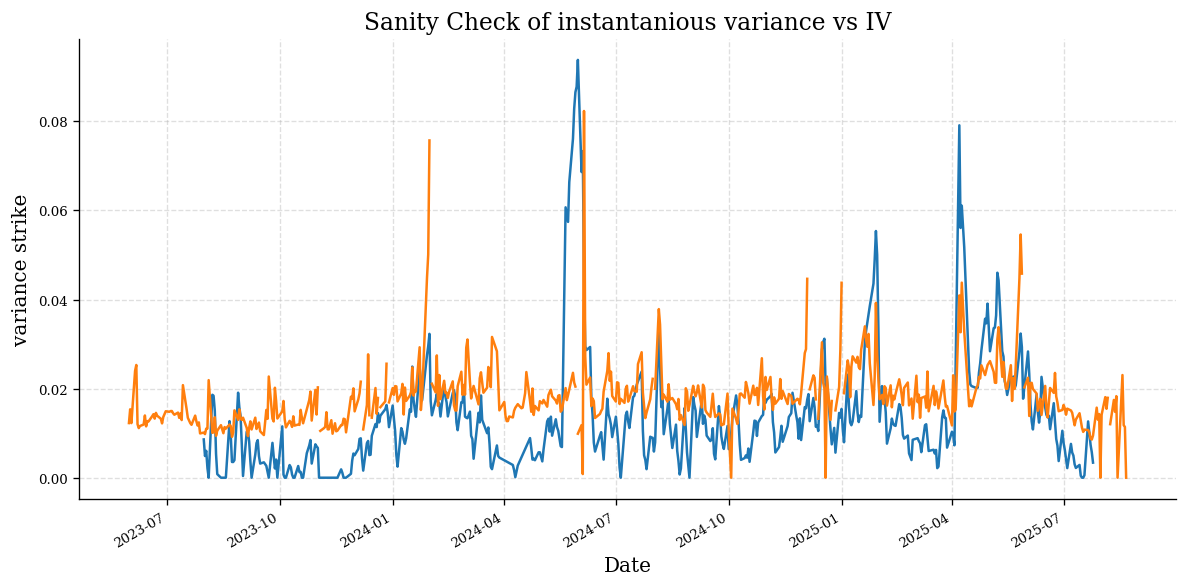

In [78]:
params['inst_variance_series'].plot()
(IV.set_index('Date')['IV']**2).plot()
plt.ylabel('variance strike')
plt.title('Sanity Check of instantanious variance vs IV')
# (vol_series**2).plot()

In [79]:
def simulate_heston_variance_cone(v0, kappa, theta, eta, days=252, n_paths=10000, offset_forecast=None):
    """
    Simulate variance process under Heston (CIR) dynamics and optionally offset cone.
    """
    dt = 1.0 / 252.0
    v = np.zeros((days, n_paths))
    v[0, :] = v0

    for t in range(1, days):
        z = np.random.randn(n_paths)
        v_prev = np.maximum(v[t-1, :], 1e-12)
        dv = kappa * (theta - v_prev) * dt + eta * np.sqrt(v_prev * dt) * z
        v[t, :] = np.maximum(v_prev + dv, 0.0)

    # Compute cone statistics
    mean_path = np.mean(v, axis=1)
    p05, p25, p50, p75, p95 = np.percentile(v, [5, 25, 50, 75, 95], axis=1)

    if offset_forecast is not None:
        delta = offset_forecast - p50[-1]
        v = np.maximum(v + delta, 0.0)
        mean_path = np.mean(v, axis=1)
        p05, p25, p50, p75, p95 = np.percentile(v, [5, 25, 50, 75, 95], axis=1)

    cone_df = pd.DataFrame({
        'mean': mean_path,
        'p05': p05,
        'p25': p25,
        'p50': p50,
        'p75': p75,
        'p95': p95
    })

    return cone_df, v


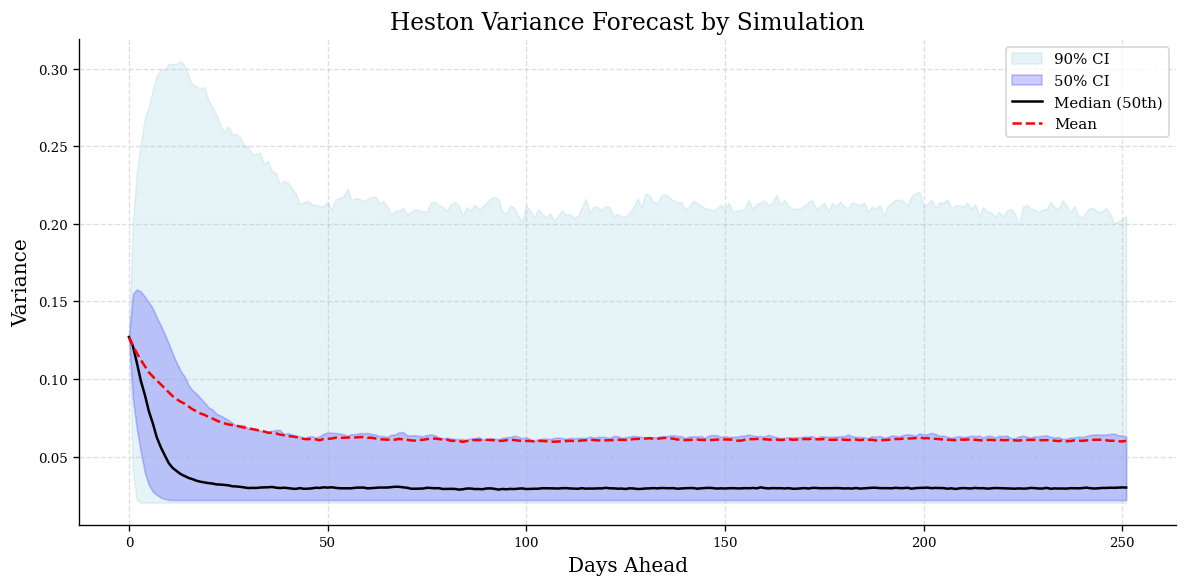

In [80]:
import datetime as dt

v0 = IV.set_index('Date').loc[dt.datetime(2025,8,20)]['IV']
cone_df, all_paths = simulate_heston_variance_cone(
    v0=v0,
    kappa=params['kappa'],
    theta=params['theta'],
    eta=params['eta'],
    days=252,
    n_paths=10000,
    offset_forecast=0.030  # e.g., your 1Y variance forecast
)

# Plot cone
plt.figure(figsize=(10,5))
plt.fill_between(range(len(cone_df)), cone_df['p05'], cone_df['p95'], color='lightblue', alpha=0.3, label='90% CI')
plt.fill_between(range(len(cone_df)), cone_df['p25'], cone_df['p75'], color='blue', alpha=0.2, label='50% CI')
plt.plot(cone_df['p50'], color='black', label='Median (50th)')
plt.plot(cone_df['mean'], color='red', linestyle='--', label='Mean')
plt.title('Heston Variance Forecast by Simulation')
plt.xlabel('Days Ahead')
plt.ylabel('Variance')
plt.legend()
plt.show()


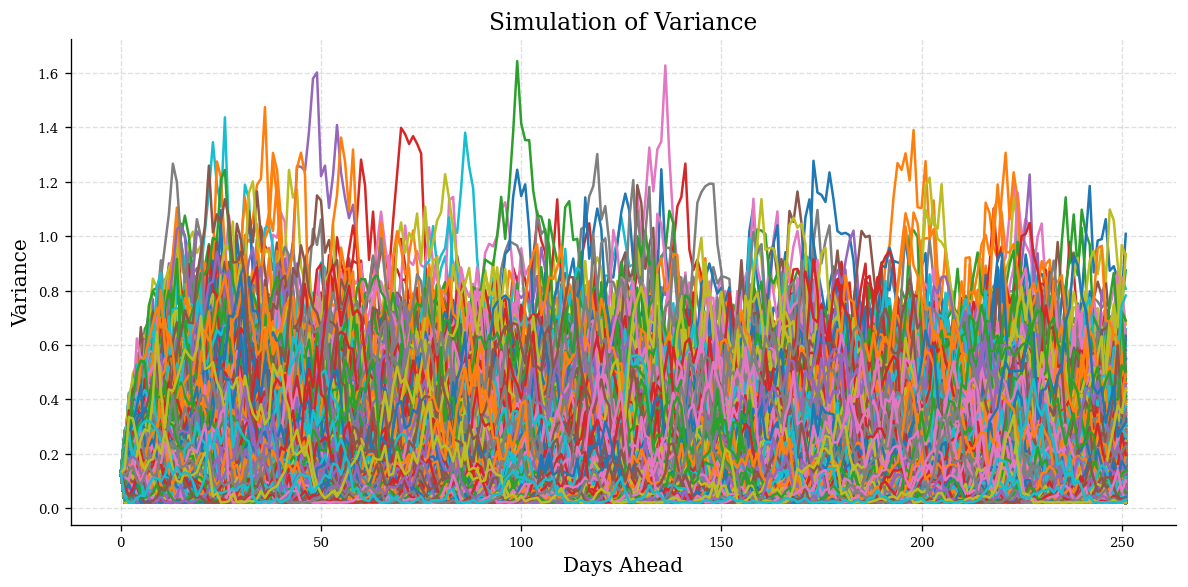

In [84]:
# all_path = pd.DataFrame(all_paths)
# all_path.index = cone_df.index
all_path.plot()
plt.title('Simulation of Variance')
plt.xlabel('Days Ahead')
plt.ylabel('Variance')
plt.legend([],[], frameon=False)
# plt.legend()
plt.show()

## Methodology 1 to determine ATM vol

In [ ]:
load_from = pd.to_datetime('1995-01-01')  # Need at least 4 years prior to the first training day
train_start_date = pd.to_datetime('2000-01-01')
test_start_date = pd.to_datetime('2019-01-01')
test_end_date = pd.to_datetime('2022-05-15')

In [ ]:
vix_data = IV.set_index('Date').dropna()
vix = vix_data['IV']
dfz1 = vix_data.reset_index().merge(df_CE1[['Date', 'NIFTY_Close']].groupby('Date').first().reset_index(), on = 'Date', how = 'inner')
spx = dfz1.set_index('Date')['NIFTY_Close']

In [ ]:
max_delta = 1000  # Number of past returns used in the computation of R_{n,t} in business days

test_start = spx.index[-1]
test_end = spx.index[-1]
train_start = spx.index[0]
tspl = True

In [ ]:

# Plot data
fig = plot_timeseries(100*vix, label='VIX', secondary=spx, secondary_label='NIFTY', 
                      add_hline=False, color_secondary='b', display_score=False)

In [ ]:

p = 1
# setting = [(1, 1), (2, 1/2)] # Our linear model
setting = [(1, (1,2)), (2, 1/2)] # Our model with a parabolic term in R_1
sol = perform_empirical_study(vol=vix, index=spx, p=p, tspl=tspl, setting=setting, train_start_date=train_start,
                                  test_start_date=test_start, test_end_date=test_end, 
                                  max_delta=250)

In [ ]:
# scores
print({key: sol[key] for key in ['train_r2', 'test_r2', 'train_rmse', 'test_rmse']})

In [ ]:
# plot timeseries of predictions vs true
pred_on_test = sol['test_pred'] * 100
pred_on_train = sol['train_pred'] * 100
target_on_test = data_between_dates(vix, start_date=test_start, end_date=test_end) * 100 
target_on_train = data_between_dates(vix, start_date=train_start, end_date=test_start) * 100
index_on_test = data_between_dates(spx, start_date=test_start, end_date=test_end)
index_on_train = data_between_dates(spx, start_date=train_start, end_date=test_start)

In [ ]:
param2 = sol['opt_params']

In [ ]:
import numpy as np

def forecast_tspl_dual(R_hist, beta_0, beta_11, beta_12, beta_2,
                       alpha_1, alpha_2, delta_1, delta_2,
                       horizon=50, n_kernel=200):
    """
    Forecast realized variance using a two-component time-shifted power-law model.

    R_hist : np.array of past realized variances (latest last)
    horizon : how many days ahead to forecast
    n_kernel : memory length (how many past days to use)
    """
    R = list(R_hist.copy())

    for _ in range(horizon):
        past = np.array(R[-n_kernel:]) if len(R) >= n_kernel else np.array(R)
        t = np.arange(1, len(past) + 1)

        # First and second kernel components
        kernel1 = (t + delta_1) ** (-alpha_1)
        kernel2 = (t + delta_2) ** (-alpha_2)

        # Weighted averages (normalized)
        k1 = np.sum(kernel1 * past) / np.sum(kernel1)
        k2 = np.sum(kernel2 * past) / np.sum(kernel2)

        # Forecast next variance value
        R_next = beta_0 + beta_11 * k1 + beta_12 * k2 + beta_2 * R[-1]
        R.append(R_next)

    return np.array(R[-horizon:])


In [ ]:
R_pred_50 = forecast_tspl_dual(vix, **param2, horizon=50)
sigma_pred_50 = np.sqrt(np.maximum(R_pred_50, 0))

In [ ]:
pd.Series(sigma_pred_50).plot()

In [ ]:
fig = plot_prediction_timeseries(y_target=target_on_test, y_pred=pred_on_test, index=index_on_test)

In [ ]:
fig = plot_prediction_timeseries(y_target=target_on_train, y_pred=pred_on_train)

In [ ]:
pred_on_test.plot()
pred_on_train.plot()
target_on_train.plot()
target_on_test.plot()

## Calibrate Parameters

In [ ]:

long_ret = var_swap2.groupby('val_date').max('Tenor').reset_index().dropna()

dtx = long_ret['val_date']
# short_ret = var_swap2[(var_swap2['Tenor'] <= 15) & (var_swap2['val_date'].isin(
#     dtx))].groupby('val_date').first().reset_index().dropna()
short_ret = var_swap2.groupby('val_date').min('Tenor').reset_index().dropna()

short_ret = short_ret[short_ret['val_date'].isin(dtx)]
dty = short_ret['val_date']
long_ret = long_ret[long_ret['val_date'].isin(dty)]

short_return = np.log(short_ret['var_strike']).diff().dropna().reset_index(drop = True)
long_return = np.log(long_ret['var_strike']).diff().dropna().reset_index(drop = True)

spot_series = short_ret[['val_date', 'spot']].set_index('val_date')['spot']
short_varswap = short_ret.set_index('val_date')['var_strike']
long_varswap = long_ret.set_index('val_date')['var_strike']



var_retrun = {1: short_return,
              3: long_return}

varswap_returns_by_tenor = var_retrun.copy()
short_tenor_months = 1# int(np.ceil(list(var_retrun.keys())[0]))
long_tenor_months = 3 #int(np.ceil(list(var_retrun.keys())[1]))

In [ ]:
get_heston_parameters_from_varswaps(
    spot_series, short_varswap, long_varswap, varswap_returns_by_tenor, short_tenor_months,
    long_tenor_months, delta_days= 1)

In [ ]:
heston_param = get_heston_parameters_from_varswaps(
    spot_series, short_varswap, long_varswap, varswap_returns_by_tenor, short_tenor_months,
    long_tenor_months, delta_days= 1)

kappa_ = heston_param['kappa']
theta_ = heston_param['theta']
eta_ = heston_param['eta']
rho_ = heston_param['rho']
lambda_ = heston_param['lambda']
v0_series = heston_param['inst_variance_series']

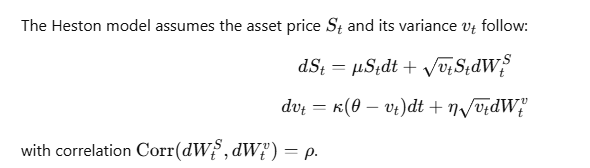

In [ ]:
# bounds = [
#             (1e-6, 1.0),   # v0
#             (1e-6, 1.0),   # theta
#             (0.01, 5.0),   # kappa
#             (0.01, 1.0),   # sigma
#             (-0.99, 0.0)   # rho
#         ]

Market option prices → Compute BS IV → (Optional) Variance swaps → Calibrate Heston (v0, θ, κ, σ, ρ) → Price options with Heston → Invert to model IV → Compare / backtest

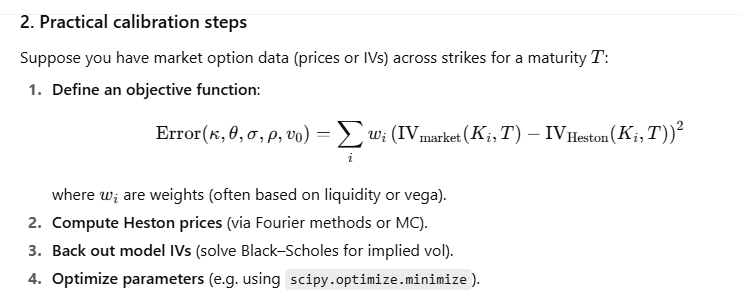

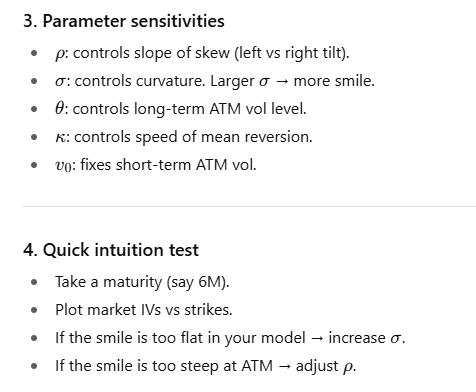

In [ ]:
kappa_, theta_, eta_, rho_, lambda_

### Options - Initial Parameters Scanner using the RMSE Function

To evaluate the quality of the model in fitting call option prices, we can use the Root Mean Square Error (RMSE) function.
-  The RMSE is defined as:

$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (P_{\text{obs},i} - P_{\text{model},i})^2}
$$

- **$P_{\text{obs},i}$**: The observed (market) price of the ith call option.
- **$P_{\text{model},i}$**: The model-predicted price of the ith call option.
- **$N$**: The total number of observations.



#### 1. **Geometric Brownian Motion (GBM)**

The GBM model is one of the foundational models for option pricing, especially known for its use in the Black-Scholes formula. Under this framework, the stock price is assumed to follow a geometric Brownian motion with constant volatility, also termed as 'implied volatility'.

###### Equation
$$ dS(t) = \mu S(t) dt + \sigma S(t) dW(t) $$

##### Calibration Goal:

- **Implied Volatility:** We aim to calibrate the constant volatility parameter **$\sigma$** such that the model prices are as close as possible to the observed market prices.

#### 2. **Heston Model**

The Heston model, on the other hand, is a more advanced stochastic volatility model. It assumes that the volatility of the asset is not constant, nor even deterministic, but follows a random process.

###### Equation
$$ dS(t) = (r-q) S(t) dt + \sqrt{v(t)} S(t) dW_1(t) $$
$$ dv(t) = \kappa (\theta - v(t)) dt + \eta \sqrt{v(t)} dW_2(t) $$

##### Calibration Goal:

Our aim is to calibrate the model parameters, including the long-term mean volatility **$\theta$**, the mean-reversion rate **$\kappa$**, the correlation **$\rho$** between the two  Wiener processes, the initial variance **$\nu_0$**, and the volatility of the volatility parameter **$\eta$**. 
We will leverage two different calibration methods:

- **Nelson's Gradient-Free Approach:** A sophisticated optimization technique that attempts to locate the best parameter values without the explicit need for gradient information.

- **BLSF Algorithm:** An advanced method known for its robustness in finding optimal solutions.

---

- mean-reversion rate **$\kappa$**,
- long-term mean volatility **$\theta$**,
- the volatility of the volatility parameter **$\lambda$**,
- correlation **$\rho$** between the two  Wiener processes,
- the initial variance **$\nu_0$**.

In [ ]:
import cmath  # For Operations on complex numbers

def myRange(start, finish, increment):
    myZero = 1e-17 
    while (start <= finish+myZero): 
        yield start  
        start += increment 
        
# defining a function to perform periodic linear extension mapping
def paramMapping(x, c, d):

    if ((x>=c) & (x<=d)):  # checking if x is between c and d
        y = x  # assigning x to y
    else:
        range = d-c  # calculating the difference between d and c
        n = math.floor((x-c)/range)  # calculating the floor value of the division
        if (n%2 == 0):  # checking if n is even
            y = x - n*range  # calculating y based on n and range
        else:
            y = d + n*range - (x-c)  # calculating y based on d, n, range and x
            
    return y  # returning the calculated y value

# defining a function to calculate the error value
def eValue(params, *args):
    
    marketPrices = args[0]  # extracting market prices from args
    maturities = args[1]  # extracting maturities from args
    strikes = args[2]  # extracting strikes from args
    r = args[3]  # extracting r value from args
    q = args[4]  # extracting q value from args
    S0 = args[5]  # extracting initial stock price from args
    alpha = args[6]  # extracting alpha value from args
    eta = args[7]  # extracting eta value from args
    n = args[8]  # extracting n value from args
    model = args[9]  # extracting model type from args

    lenT = len(maturities)  # getting the length of maturities
    lenK = len(strikes)  # getting the length of strikes
    
    modelPrices = np.zeros((lenT, lenK))  # initializing an array of zeros for model prices

    count = 0  # initializing a counter
    mae = 0  # initializing the mean absolute error
    for i in range(lenT):  # looping through each maturity
        for j in range(lenK):  # looping through each strike
            count  = count+1  # incrementing the counter
            T = maturities[i]  # getting the current maturity
            K = strikes[j]  # getting the current strike
            [km, cT_km] = genericFFT(params, S0, K, r, q, T, alpha, eta, n, model)  # computing km and cT_km using the genericFFT function
            modelPrices[i,j] = cT_km[0]  # assigning the calculated model price to the matrix
            tmp = marketPrices[i,j]-modelPrices[i,j]  # computing the difference between market and model prices
            mae += tmp**2  # accumulating the square of differences
    
    rmse = math.sqrt(mae/count)  # calculating the root mean square error
    return rmse  # returning the calculated error

# defining a function to compute the characteristic function of a given model
def generic_CF(u, params, S0, r, q, T, model):
    # logic for Geometric Brownian Motion (GBM) model
    if (model == 'GBM'):
        sig = params[0]  # extracting sigma from parameters
        mu = np.log(S0) + (r-q-sig**2/2)*T  # calculating mu value
        a = sig*np.sqrt(T)  # calculating a value
        phi = np.exp(1j*mu*u-(a*u)**2/2)  # calculating the characteristic function for GBM
        
    # logic for Heston model
    elif(model == 'Heston'):
        # extracting parameters for the Heston model
        kappa  = params[0]
        theta  = params[1]
        sigma  = params[2]
        rho    = params[3]
        v0     = params[4]
        
        # mapping parameters to specific ranges
        kappa = paramMapping(kappa,0.1, 20)
        theta = paramMapping(theta,0.001, 0.4)
        sigma = paramMapping(sigma,0.01, 0.6)
        rho   = paramMapping(rho  ,-1.0, 1.0)
        v0    = paramMapping(v0   ,0.005, 0.25)
        
        # calculations for Heston model characteristic function
        tmp = (kappa-1j*rho*sigma*u)
        g = np.sqrt((sigma**2)*(u**2+1j*u)+tmp**2)
        pow1 = 2*kappa*theta/(sigma**2)
        numer1 = (kappa*theta*T*tmp)/(sigma**2) + 1j*u*T*r + 1j*u*math.log(S0)
        log_denum1 = pow1 * np.log(np.cosh(g*T/2)+(tmp/g)*np.sinh(g*T/2))
        tmp2 = ((u*u+1j*u)*v0)/(g/np.tanh(g*T/2)+tmp)
        log_phi = numer1 - log_denum1 - tmp2
        phi = np.exp(log_phi)
        
    # logic for Variance Gamma (VG) model
    elif (model == 'VG'):
        # extracting parameters for the VG model
        sigma  = params[0]
        nu     = params[1]
        theta  = params[2]
        
        # calculations for VG model characteristic function
        if (nu == 0):
            mu = math.log(S0) + (r-q - theta -0.5*sigma**2)*T
            phi  = math.exp(1j*u*mu) * math.exp((1j*theta*u-0.5*sigma**2*u**2)*T)
        else:
            mu  = math.log(S0) + (r-q + math.log(1-theta*nu-0.5*sigma**2*nu)/nu)*T
            phi = cmath.exp(1j*u*mu)*((1-1j*nu*theta*u+0.5*nu*sigma**2*u**2)**(-T/nu))

    return phi  # returning the calculated characteristic function


# defining a function to compute option prices using the Fast Fourier Transform (FFT) method
def genericFFT(params, S0, K, r, q, T, alpha, eta, n, model):
    
    N = 2**n  # calculating the size of the FFT
    
    lda = (2*np.pi/N)/eta  # calculating the step-size in log strike space
    
    beta = np.log(K)  # choosing beta as the logarithm of strike price
    
    km = np.zeros((N))  # initializing an array of zeros for km values
    xX = np.zeros((N))  # initializing an array of zeros for x values
    
    df = math.exp(-r*T)  # calculating the discount factor
    
    nuJ = np.arange(N)*eta  # creating an array of nu values multiplied by eta

    psi_nuJ = generic_CF(nuJ-(alpha+1)*1j, params, S0, r, q, T, model)/((alpha + 1j*nuJ)*(alpha+1+1j*nuJ))  # calculating psi_nu values using the characteristic function
    
    # loop to calculate x values for FFT
    for j in range(N):  
        km[j] = beta+j*lda  # calculating km values
        if j == 0:
            wJ = (eta/2)  # adjusting the weight for the first iteration
        else:
            wJ = eta  # using eta as the weight for subsequent iterations
        xX[j] = cmath.exp(-1j*beta*nuJ[j])*df*psi_nuJ[j]*wJ  # calculating x values for FFT
     
    yY = np.fft.fft(xX)  # performing the FFT on x values
    cT_km = np.zeros((N))  # initializing an array of zeros for cT_km values

    # loop to calculate option prices using the FFT results
    for i in range(N):
        multiplier = math.exp(-alpha*km[i])/math.pi  # calculating the multiplier for option prices
        cT_km[i] = multiplier*np.real(yY[i])  # calculating option prices
    
    return km, cT_km  # returning km values and option prices

In [ ]:
val

In [ ]:
dt1 = df_CE1.Date.unique()[-200]
data = df_CE1[(df_CE1['Date'] == dt1) & (~df_CE1['IV_QLIB'].isna())]
# smoothed = data.set_index('Strike Price')[['IV', 'IV_QLIB']].sort_index().rolling(window=5).mean().rolling(window=5).mean().rolling(window=5).mean()
# smoothed.plot()


df = data.set_index('Strike Price')[['IV', 'IV_QLIB']].sort_index()

window_length = 3  
polyorder = 1

df['IV_smooth'] = savgol_filter(df['IV'], window_length, polyorder)
df['IV_QLIB_smooth'] = savgol_filter(df['IV_QLIB'], window_length, polyorder)

df[['IV_smooth', 'IV_QLIB_smooth']].plot()

val = data[data['moneyness'] == 'ATM']
K = val['Strike Price']
T_days = val['T2E'].dt.days
T_years = T_days / 365  # converting the time to expiration to years

# dividend rate
q = 0

# risk free rate
r = val['rate']

# spot price
S0 = val['NIFTY_Close']  # setting the spot price of the stock to the variable current_stock_price

# price
P_call = val['Close']

In [ ]:
model = 'Heston'
alpha = 1.5
eta = 0.2

# setting the n parameter to 12
n = 12

# defining a tuple of parameters for the first set of model parameters
params1 = (kappa_, theta_, eta_, rho_, lambda_)

# defining a tuple of parameters for the second set of model parameters
params2 = (kappa_*2, theta_*2, eta_*2, rho_*2, lambda_*2)

#### start from here the function calculate the minimum value and then is used by the BFS algo to establish further

In [ ]:
sample_df = df_CE1[df_CE1['Date'].isin(df_CE1.Date.unique()[-50:-20])]

In [ ]:
params2

In [ ]:
strikes = np.sort(sample_df['Strike Price'].unique())  
    
    # extracting unique maturity days from the DataFrame and sorting them
maturities = np.sort(sample_df['T2E'].dt.days.unique())

# creating a meshgrid for strikes and maturities, essential for 3D plotting
X, Y = np.meshgrid(strikes, maturities)  

# initializing an empty array to store option prices
callPrices = np.empty([len(maturities), len(strikes)])  
for i in range(len(maturities)): 
        s = sample_df[sample_df['T2E'].dt.days == maturities[i]]['Strike Price']  
        
        # selecting corresponding option prices for the given maturity
        price = sample_df[sample_df['T2E'].dt.days == maturities[i]]['Close']  
        
        # using linear interpolation to estimate option prices for all strikes
        f = interpolate.interp1d(s, price, kind='linear', bounds_error=False, fill_value="extrapolate")  
        
        # storing interpolated prices into the callPrices array
        callPrices[i, :] = f(strikes)

In [ ]:
iArray = []

rmseArray = []
rmseMin = 1e10  
option_type = "Call"
marketPrices = callPrices
# converting maturities to years from days
maturities_years = maturities / 365.0

my_dot_printer = DotPrinter(f"\rSearching for the Initial Starting Parameters")
my_dot_printer.start()

# looping through a range of 'i' values from 0 to 1 with a step of 0.05
for i in myRange(0, 1, 0.05):
    # calculating a weighted average of params1 and params2 based on 'i'
    params = i * np.array(params1) + (1.0 - i) * np.array(params2)
    
    # appending the current value of 'i' to the iArray list
    iArray.append(i)
    
    # calculating the RMSE using the eValue function from the mfc module
    rmse = eValue(params, marketPrices, maturities_years, strikes, r, q, S0, alpha, eta, n, model)
    
    # appending the calculated RMSE to the rmseArray list
    rmseArray.append(rmse)
    
    # checking if the calculated RMSE is less than the current minimum RMSE
    if rmse < rmseMin:
        rmseMin = rmse  # updating the minimum RMSE
        optimParams = params  # storing the parameters that resulted in the minimum RMSE

my_dot_printer.stop()
print(f"\rInitial Optimal Parameters --> Found - The optimization process will start from here", end=" " * 50)
print("")

# printing the minimum RMSE and the optimal parameters on the same line
print("Minimum RMSE: {} - Optimal Initial Parameters: {}".format(rmseMin, optimParams))

In [ ]:
# initializing the arguments for the optimization function
arg = (marketPrices, maturities_years, strikes, r, q, S0, alpha, eta, n, model)

# starting the animation
my_dot_printer = DotPrinter(f"\rMinimization Process - BLSF Algorithm")
my_dot_printer.start()

# performing the optimization using the fmin_bfgs function from scipy.optimize
# t contains the output including optimal parameters and function value
t = fmin_bfgs(
    mfc.eValue,              # function to be minimized
    list(params1),       # initial parameter guess - same starting point
    args=arg,                # extra arguments passed to mfc.eValue
    maxiter = 10,            # maximum number of iterations - 10
    disp = False,            # flag to display convergence messages
    retall = False,          # flag to return all parameter vectors
    full_output = True       # flag to return fopt, iterations, etc. in addition to xopt
)

my_dot_printer.stop()
print(f"\rBLSF Minimization Process --> Done", end=" " * 150)
print("")

# assigning the minimum RMSE and the optimal parameters
rmseMinBLSF = t[1]
optimParamsBLSF = t[0]

# printing the minimum RMSE and the optimal parameters on the same line
print("Minimum RMSE: {} - Optimal BLSF Parameters: {}".format(rmseMinBLSF, optimParamsBLSF))

In [ ]:
## PRICING WITH HESTON PARAMETERS

# def heston_mc_price(S0, K, r, T, v0, theta, kappa, sigma, rho, n_paths=100000, n_steps=100):
#     dt = T / n_steps
#     S = np.full(n_paths, S0)
#     v = np.full(n_paths, v0)

#     for _ in range(n_steps):
#         z1 = np.random.normal(size=n_paths)
#         z2 = np.random.normal(size=n_paths)
#         z2 = rho * z1 + np.sqrt(1 - rho**2) * z2  # correlate

#         v = np.maximum(0, v + kappa * (theta - v) * dt + sigma * np.sqrt(v * dt) * z1)
#         S *= np.exp((r - 0.5 * v) * dt + np.sqrt(v * dt) * z2)

#     payoff = np.maximum(S - K, 0)
#     return np.exp(-r * T) * np.mean(payoff)

def heston_mc_price(S0, K, r, T, v0, theta, kappa, sigma, rho, n_paths=100000, n_steps=100):
    dt = T / n_steps
    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    for _ in range(n_steps):
        z1 = np.random.normal(size=n_paths)
        z_indep = np.random.normal(size=n_paths)   # independent draw
        z2 = rho * z1 + np.sqrt(1 - rho**2) * z_indep  # correlated normal

        v = np.maximum(
            0,
            v + kappa * (theta - v) * dt + sigma * np.sqrt(v * dt) * z1
        )
        S *= np.exp((r - 0.5 * v) * dt + np.sqrt(v * dt) * z2)

    payoff = np.maximum(S - K, 0)
    
    terminal_variance = np.mean(v)
    price = np.exp(-r * T) * np.mean(payoff)

    # return price, payoff, v
    return terminal_variance




In [ ]:
# --- Black–Scholes Call Price ---
def bs_call_price(S0, K, T, r, sigma):
    if sigma <= 0:
        return max(0.0, S0 - K * np.exp(-r*T))
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# # --- Implied Volatility via root-finding ---
# def implied_vol(price, S0, K, T, r):
#     try:
#         return brentq(
#             lambda sigma: bs_call_price(S0, K, T, r, sigma) - price,
#             1e-6, 5.0
#         )
#     except ValueError:
#         return np.nan  # fallback if no root found

# --- Heston Monte Carlo to compute IV curve ---
def heston_mc_iv_curve(S0, strikes, r, T, v0, theta, kappa, sigma, rho,
                       n_paths=50000, n_steps=200):
    dt = T / n_steps
    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    for _ in range(n_steps):
        z1 = np.random.normal(size=n_paths)
        z_indep = np.random.normal(size=n_paths)
        z2 = rho*z1 + np.sqrt(1-rho**2)*z_indep

        v = np.maximum(0, v + kappa*(theta-v)*dt + sigma*np.sqrt(v*dt)*z1)
        S *= np.exp((r-0.5*v)*dt + np.sqrt(v*dt)*z2)

    ivs = {}
    for K in strikes:
        payoff = np.maximum(S - K, 0)
        call_price = np.exp(-r*T) * np.mean(payoff)
        # ivs[K] = implied_vol(call_price, S0, K, T, r)
        ivs[K] = calculate_implied_volatility(call_price, S0, K, T, r, 'call')
        


    return ivs


In [ ]:

S0 = var_swap['spot'].iloc[-1]
K_ = np.arange(1850, 2500, 50)
r = var_swap['rate'].iloc[-30:].mean()
T_ = np.arange(1,93,7)
v0 = df_CE1[df_CE1['moneyness'] == 'ATM']['IV'][-30:].mean()**2
sigma_ = df_CE1[df_CE1['moneyness'] == 'ATM']['IV'][-30:].std()

price_per_T = []
for T in T_:
    price_per_strike = []
    for K in K_:
        val = heston_mc_price(S0, K, r, T, v0, theta_, kappa_, sigma_, rho_, 100000, 100)
        price_per_strike.append(val)
    price_per_T.append(price_per_strike)

In [ ]:
x = heston_mc_iv_curve(S0, K_, r, T/365, v0, theta_, kappa_, sigma_, rho_)

In [ ]:
c = []
for a,b in x.items():
    l = [a,b]
    c.append(l)

In [ ]:
pd.DataFrame(c).set_index(0).sort_index().plot()

In [ ]:
# implied_vol(20, S0, K_[0], T, r)
calculate_implied_volatility(1500, S0, K_[50], T/365, r,'call')

In [ ]:
########CHECK##---BACKTEST
a = list(option_curve_PE.keys())[500]
v_s1 = var_swap[var_swap['val_date'] == a].dropna()
z1 = df_CE1[df_CE1['Date'] == a]
z1 = z1[z1['IV'] != 0]


S0 = v_s1['spot'].iloc[-1]
K_ = z1['Strike Price'].unique()
r = var_swap['rate'].mean()
T_ = z1['T2E'].unique().days#/365
v0 = z1[z1['moneyness'] == 'ATM']['IV'].mean()
sigma_ = z1['IV'].max()

price_per_T = []
# for T in T_:
#     price_per_strike = []
#     for K in K_:
#         # val = heston_mc_price(S0, K, r, T, v0, theta_, kappa_, sigma_, rho_, 100000, 100)
#         val = heston_mc_iv_curve(S0, K, r, T, v0, theta_, kappa_, sigma_, rho_, 100000, 100)

#         price_per_strike.append(val)
#     price_per_T.append(price_per_strike)

for T in T_:
    val = heston_mc_iv_curve(S0, K, r, T/365, v0, theta_, kappa_, sigma_, rho_, 100000, 100)
    price_per_T.append(price_per_strike)

vols_forecasted = pd.DataFrame(price_per_T)
vols_forecasted.columns = K_
vols_forecasted.index = T_#*365
# np.sqrt(vols_forecasted)
vols_forecasted



In [ ]:
np.sqrt(vols_forecasted.iloc[1].sort_index()).plot()
# plt.axhline(np.sqrt(v0), color = 'red')

In [ ]:
z1_ = z1.copy()
z2 = z1_.pivot_table(index = 'T2E', columns = 'Strike Price', values = 'IV')
z2

In [ ]:
def plot_surface_comparison(grid1: pd.DataFrame, grid2: pd.DataFrame, title1="Grid 1", title2="Grid 2"):
    # Make sure index is numeric (convert timedelta to days if needed)
    if pd.api.types.is_timedelta64_dtype(grid1.index):
        grid1 = grid1.copy()
        grid1.index = grid1.index.days.astype(float)

    if pd.api.types.is_timedelta64_dtype(grid2.index):
        grid2 = grid2.copy()
        grid2.index = grid2.index.days.astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Heatmap 1
    im1 = axes[0].imshow(grid1.values, aspect='auto', 
                         extent=[grid1.columns.min(), grid1.columns.max(),
                                 grid1.index.max(), grid1.index.min()],
                         cmap="viridis")
    axes[0].set_title(title1)
    axes[0].set_xlabel("Strike")
    axes[0].set_ylabel("Time to Expiry (days)")
    fig.colorbar(im1, ax=axes[0])

    # Heatmap 2
    im2 = axes[1].imshow(grid2.values, aspect='auto', 
                         extent=[grid2.columns.min(), grid2.columns.max(),
                                 grid2.index.max(), grid2.index.min()],
                         cmap="viridis")
    axes[1].set_title(title2)
    axes[1].set_xlabel("Strike")
    fig.colorbar(im2, ax=axes[1])

    plt.suptitle("Comparison of Two Surfaces")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_surface_comparison(np.sqrt(vols_forecasted), z2, title1 = 'Heston Forecasted IV', title2 = 'Actual IV')

In [ ]:

def compare_iv_at_t(grid1: pd.DataFrame, grid2: pd.DataFrame, t_value, label1="Grid1", label2="Grid2"):
    """
    Compare IV across strikes for a given time to expiry t_value.
    t_value: float (if your index is in days) or pd.Timedelta (if index is timedelta)
    """
    # Convert timedelta index to float days if needed
    def index_as_days(df):
        if pd.api.types.is_timedelta64_dtype(df.index):
            return df.index.days.astype(float)
        return df.index.astype(float)
    
    grid1_index_days = index_as_days(grid1)
    grid2_index_days = index_as_days(grid2)
    
    # Find the closest row to t_value
    idx1 = (grid1_index_days - t_value).argmin()
    idx2 = (grid2_index_days - t_value).argmin()
    
    row1 = grid1.iloc[idx1]
    row2 = grid2.iloc[idx2]
    
    plt.figure(figsize=(10,6))
    plt.plot(grid1.columns, row1.values, marker='o', label=label1)
    plt.plot(grid2.columns, row2.values, marker='x', label=label2)
    plt.title(f"IV across strikes at ~{t_value} days to expiry")
    plt.xlabel("Strike")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
compare_iv_at_t(np.sqrt(vols_forecasted), z2, t_value=21, label1='Heston Forecasted IV', label2='Actual IV')

In [ ]:
"""
Heston calibration utility
- Semi-analytic Heston pricing via Heston (1993) integrals (P1, P2) using numerical integration
- Implied vol via Brent solver
- Calibration using scipy.optimize (differential_evolution + least_squares)

Usage:
    from heston_calibration import calibrate_heston, heston_price_call, implied_vol

    params = calibrate_heston(options_df, S0, r, q, T, initial_guess=None)

Requires: numpy, scipy, pandas
"""

import numpy as np
import math
from scipy import integrate, optimize

# ---------------------- characteristic function ----------------------

def _heston_cf(u, params, S0, r, q, T, j):
    # params: dict with kappa, theta, sigma, rho, v0
    kappa = params['kappa']
    theta = params['theta']
    sigma = params['eta']
    rho = params['rho']
    v0 = params['v0']

    # j = 1 or 2
    if j == 1:
        phi = 0.5
        u_shift = u - 1j * 0.5
    else:
        phi = 0.5
        u_shift = u

    # The standard Heston CF uses different formulations for P1 and P2 via parameterization
    a = kappa * theta
    b = kappa - (rho * sigma) * (1j * u_shift)
    d = np.sqrt((rho * sigma * 1j * u_shift - b) ** 2 + (sigma ** 2) * (1j * u_shift + u_shift ** 2))
    g = (b - d) / (b + d)

    # Avoid branch issues
    exp_dT = np.exp(-d * T)

    C = (r - q) * 1j * u_shift * T + (a / (sigma ** 2)) * ((b - d) * T - 2.0 * np.log((1 - g * exp_dT) / (1 - g)))
    D = ((b - d) / (sigma ** 2)) * ((1 - exp_dT) / (1 - g * exp_dT))

    cf = np.exp(C + D * v0 + 1j * u_shift * np.log(S0 * np.exp(-q * T)))
    return cf

# ---------------------- Heston integrand for P1 and P2 ----------------------

def _integrand_P(u, params, S0, K, r, q, T, j):
    # integrand for Pj: Re( e^{-i u ln K} * phi_j(u) / (i u) )
    cf = _heston_cf(u, params, S0, r, q, T, j)
    ex = np.exp(-1j * u * np.log(K)) * cf
    denom = 1j * u
    val = ex / denom
    return np.real(val)


def _Pj(j, params, S0, K, r, q, T):
    # Pj = 0.5 + (1/pi) * integral_0^inf integrand du
    integrand = lambda uu: _integrand_P(uu, params, S0, K, r, q, T, j)
    # integrate with quad, break into pieces for stability
    limit = 100
    try:
        val, err = integrate.quad(integrand, 0.0, limit, limit=100, epsabs=1e-8, epsrel=1e-6)
    except Exception:
        # fallback to truncation
        val, err = integrate.quad(integrand, 1e-8, 50.0, limit=100, epsabs=1e-7, epsrel=1e-5)

    P = 0.5 + val / math.pi
    return P

# ---------------------- price & implied vol ----------------------

def heston_price_call(S0, K, r, q, T, params):
    # Using Heston formula: C = S*e^{-qT}*P1 - K*e^{-rT}*P2
    P1 = _Pj(1, params, S0, K, r, q, T)
    P2 = _Pj(2, params, S0, K, r, q, T)
    return S0 * math.exp(-q * T) * P1 - K * math.exp(-r * T) * P2


def _bs_price_call(S, K, r, q, T, sigma):
    # Black-Scholes call price (continuous dividend yield q)
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    from math import erf, sqrt
    # use norm.cdf from scipy if available
    try:
        from scipy.stats import norm
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    except Exception:
        # approximate
        cdf = lambda x: 0.5 * (1 + math.erf(x / math.sqrt(2)))
        return S * math.exp(-q * T) * cdf(d1) - K * math.exp(-r * T) * cdf(d2)


def implied_vol_from_price(C_market, S, K, r, q, T):
    # Brent root find between tiny vol and big vol
    if C_market <= max(0.0, S * math.exp(-q * T) - K * math.exp(-r * T)) + 1e-12:
        return 0.0

    def objective(sigma):
        return _bs_price_call(S, K, r, q, T, sigma) - C_market

    try:
        vol = optimize.brentq(objective, 1e-8, 5.0, maxiter=200, xtol=1e-8)
    except Exception:
        # fallback: use secant
        vol = optimize.newton(lambda x: objective(x), 0.2, tol=1e-6, maxiter=50)
    return float(vol)

# ---------------------- calibration objective ----------------------

def _calibration_objective(param_vec, option_indicators, S0, r, q):
    # param_vec: [kappa, theta, eta, rho, v0]
    kappa, theta, eta, rho, v0 = param_vec
    params = {'kappa': max(1e-6, kappa), 'theta': max(1e-8, theta), 'eta': max(1e-8, eta), 'rho': float(np.clip(rho, -0.999, 0.999)), 'v0': max(1e-8, v0)}

    errs = []
    for row in option_indicators:
        K = row['K']
        T = row['T']
        market_iv = row['iv']
        market_price = row['price']

        # model price
        try:
            C_model = heston_price_call(S0, K, r, q, T, params)
        except Exception:
            C_model = 0.0

        # implied vol from model
        try:
            iv_model = implied_vol_from_price(C_model, S0, K, r, q, T)
        except Exception:
            iv_model = np.nan

        # weight by vega-like factor: higher weight near ATM
        moneyness = np.log(S0 / K) / math.sqrt(max(1e-12, T)) if T > 0 else 0
        weight = math.exp(-0.5 * (moneyness ** 2))  # Gaussian weight on moneyness

        if np.isnan(iv_model) or np.isnan(market_iv):
            continue

        errs.append(weight * (iv_model - market_iv))

    return np.array(errs)

# ---------------------- public calibrator ----------------------

def calibrate_heston(options_df, S0, r, q, initial_guess=None, bounds=None, verbose=True):
    """
    options_df should have columns: ['strike','time_to_expiry','mid_price','iv']
    time_to_expiry in years (T)
    iv is market implied vol
    """
    # prepare option_indicators list
    option_indicators = []
    for _, row in options_df.iterrows():
        option_indicators.append({'K': float(row['strike']), 'T': float(row['time_to_expiry']), 'price': float(row['mid_price']), 'iv': float(row['iv'])})

    # initial guess
    if initial_guess is None:
        # kappa, theta, eta, rho, v0
        initial_guess = np.array([1.0, 0.04, 0.5, -0.5, 0.04])
    else:
        initial_guess = np.asarray(initial_guess, dtype=float)

    if bounds is None:
        lb = [1e-6, 1e-6, 1e-6, -0.999, 1e-8]
        ub = [20.0, 5.0, 5.0, 0.999, 5.0]
    else:
        lb, ub = bounds

    # global optimizer to find good start: differential evolution
    def obj_de(vec):
        err = _calibration_objective(vec, option_indicators, S0, r, q)
        return float(np.nansum(err ** 2))

    if verbose:
        print("Running differential_evolution for global search...")
    result_de = optimize.differential_evolution(obj_de, bounds=list(zip(lb, ub)), maxiter=30, popsize=15)

    x0 = result_de.x
    if verbose:
        print("DE finished, now local least_squares...")

    # local least squares on implied vol errors
    # res_ls = optimize.least_squares(lambda v: _calibration_objective(v, option_indicators, S0, r, q), x0, bounds=(lb, ub), xtol=1e-8, ftol=1e-8, max_nfev=200)

    res_ls = optimize.least_squares(lambda v: _calibration_objective(v, option_indicators, S0, r, q,
                                                                   vega_power=1.0,
                                                                   moneyness_scale=0.25,
                                                                   wing_boost=0.75,
                                                                   reg_lambda=1e-6),
                                x0, bounds=(lb, ub),
                                xtol=1e-8, ftol=1e-8, max_nfev=500)


    kappa, theta, eta, rho, v0 = res_ls.x
    fitted = {
        'kappa': float(kappa),
        'theta': float(theta),
        'eta': float(eta),
        'rho': float(rho),
        'v0': float(v0),
        'success': res_ls.success,
        'message': res_ls.message
    }
    return fitted


rop-in code (replace _calibration_objective + helpers)

Replace your existing _calibration_objective with the code below. It computes model IVs, BS vegas, constructs weights = vega * moneyness_weight and returns weighted residuals (so least_squares does sum of squares on those).

In [ ]:
# ------------------ helpers for weighting & vega ------------------

def _bs_vega(S, K, T, r, q, sigma):
    """Black-Scholes vega for call (per 1 vol). sigma is in decimals."""
    if T <= 0 or sigma <= 0:
        return 0.0
    from scipy.stats import norm
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)


def _moneyness_log(K, S0, r, q, T):
    """Log-moneyness using forward: ln(K/F) where F = S0 * exp((r-q)T)."""
    F = S0 * math.exp((r - q) * T)
    return math.log(K / F)  # note: positive for OTM calls (K>F)


def _calibration_objective(param_vec, option_indicators, S0, r, q, 
                           vega_power=1.0, moneyness_scale=0.25, wing_boost=1.0, reg_lambda=1e-6):
    """
    Weighted residuals on implied vols.

    - vega_power: raise vega to this power (1.0 standard). Lower <1 spreads weight to wings.
    - moneyness_scale: controls how quickly moneyness downweights ATM (in log-strike units).
    - wing_boost: multiplicative factor to boost wings (abs(k) large) >1 gives wings more weight.
    - reg_lambda: small regularization on params to stabilize.
    """
    kappa, theta, eta, rho, v0 = param_vec
    # enforce bounds inside objective to avoid invalid math
    params = {
        'kappa': max(1e-6, kappa),
        'theta': max(1e-8, theta),
        'eta': max(1e-8, eta),
        'rho': float(np.clip(rho, -0.999, 0.999)),
        'v0': max(1e-8, v0)
    }

    residuals = []

    for row in option_indicators:
        K = float(row['K'])
        T = float(row['T'])
        market_iv = float(row['iv'])
        market_price = float(row.get('price', np.nan))

        # model price and implied vol
        try:
            C_model = heston_price_call(S0, K, r, q, T, params)
            iv_model = implied_vol_from_price(C_model, S0, K, r, q, T)
        except Exception:
            continue

        if np.isnan(iv_model) or np.isnan(market_iv):
            continue

        # weight by BS vega (computed at market IV as proxy)
        vega = _bs_vega(S0, K, T, r, q, market_iv)
        # avoid zero weight — add tiny floor
        vega = max(vega, 1e-8)
        vega_weight = (vega ** float(vega_power))

        # moneyness weight: Gaussian centered at ATM in log-moneyness space
        k = _moneyness_log(K, S0, r, q, T)
        # standard gaussian-like downweighting for ATM; wing_boost multiplies wings
        m_weight = math.exp(-0.5 * (k / float(moneyness_scale)) ** 2)
        # give wings extra relative importance by (1 + wing_boost*|k|)
        wing_factor = 1.0 + float(wing_boost) * abs(k)

        weight = vega_weight * (1.0 - m_weight + m_weight) * wing_factor  # keep formula explicit
        # simpler: weight = vega * (1 + wing_boost*|k|)

        # residual on IV (market_iv - model_iv) scaled by weight
        res = weight * (iv_model - market_iv)
        residuals.append(res)

    # tiny regularization to prevent extreme params drifting
    # penalize very large theta / v0 / eta somewhat (in variance units)
    reg = reg_lambda * np.array([params['kappa'], params['theta'], params['eta'], params['rho'], params['v0']])
    # append reg as residuals (least_squares will square them)
    residuals.extend(list(reg))

    return np.array(residuals)


### Entire modification

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes call
def bs_call_price(S, K, T, r, sigma):
    if sigma * np.sqrt(T) < 1e-12:
        return max(0, S - K * np.exp(-r * T))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Implied vol
def calculate_implied_volatility(price, S, K, T, r):
    def objective(sigma):
        return bs_call_price(S, K, T, r, sigma) - price
    try:
        return brentq(objective, 1e-6, 5.0)
    except ValueError:
        return np.nan

# Heston characteristic function
def heston_cf(phi, S0, T, r, v0, theta, kappa, sigma, rho):
    i = 1j
    d = np.sqrt((rho*sigma*i*phi - kappa)**2 + sigma**2*(i*phi + phi**2))
    g = (kappa - rho*sigma*i*phi - d) / (kappa - rho*sigma*i*phi + d)
    C = r*i*phi*T + (kappa*theta/sigma**2) * ((kappa - rho*sigma*i*phi - d)*T - 2*np.log((1-g*np.exp(-d*T))/(1-g)))
    D = ((kappa - rho*sigma*i*phi - d) / sigma**2) * ((1 - np.exp(-d*T))/(1 - g*np.exp(-d*T)))
    return np.exp(C + D*v0 + i*phi*np.log(S0))

# Heston call price (semi-analytic)
def heston_call_price(S0, K, T, r, v0, theta, kappa, sigma, rho):
    def integrand(phi):
        cf = heston_cf(phi - 1j, S0, T, r, v0, theta, kappa, sigma, rho)
        return np.real(np.exp(-1j*phi*np.log(K)) * cf / (1j*phi * S0 * np.exp(-r*T)))
    # Numerical integration
    phi_vals = np.linspace(1e-5, 100, 500)
    integrand_vals = [integrand(phi) for phi in phi_vals]
    integral = np.trapz(integrand_vals, phi_vals)
    return S0 - np.sqrt(S0*K) / np.pi * integral

def heston_iv_curve(S0, strikes, T, r, v0, theta, kappa, sigma, rho):
    ivs = {}
    for K in strikes:
        price = heston_call_price(S0, K, T, r, v0, theta, kappa, sigma, rho)
        ivs[K] = calculate_implied_volatility(price, S0, K, T, r)
    return ivs

In [ ]:
S0 = 100.0
r = 0.01
q = 0.0
# build sample options_df
strikes = np.array([70,80,90,95,100,105,110,120,130], dtype=float)
T = 0.5
# assume some market iv curve
market_iv = 0.2 + 0.1 * (np.log(S0 / strikes) ** 2)
# placeholder mid_price using BS with flat vol (not true)
mid_prices = [ _bs_price_call(S0, K, r, q, T, iv) for K, iv in zip(strikes, market_iv) ]
df = pd.DataFrame({'strike': strikes, 'time_to_expiry': T, 'mid_price': mid_prices, 'iv': market_iv})

print('Calibrating to toy surface... (this is synthetic)')
fit = calibrate_heston(df, S0, r, q, verbose=True)
print('fit:', fit)

In [ ]:
theta = fit['theta']
kappa = fit['kappa']
eta = fit['eta']
rho = fit['rho']
v0 = market_iv[0]#fit['v0']

iv_curve = heston_iv_curve(S0, strikes, T, r, v0, theta, kappa, eta, rho)

# Synthetic "market IV" for comparison
market_iv = {K: 0.2 + 0.1 * (np.log(S0 / K) ** 2) for K in strikes}

# Plot
plt.plot(list(iv_curve.keys()), list(iv_curve.values()), 'o-', label="Heston IV (semi-analytic)")
plt.plot(list(market_iv.keys()), list(market_iv.values()), 'x--', label="Market IV (toy)")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.title("Heston Model vs Market IV Curve")
plt.show()


In [ ]:
plt.plot(strikes,market_iv)

In [ ]:
# Black-Scholes call
def bs_call_price(S, K, T, r, sigma):
    if sigma * np.sqrt(T) < 1e-12:  # avoid divide by zero
        return max(0, S - K * np.exp(-r * T))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Implied vol via root finder
def calculate_implied_volatility(price, S, K, T, r, option_type="call"):
    def objective(sigma):
        return bs_call_price(S, K, T, r, sigma) - price

    try:
        return brentq(objective, 1e-6, 5.0)
    except ValueError:
        return np.nan

# Heston MC -> IV curve
def heston_mc_iv_curve(S0, strikes, r, T, v0, theta, kappa, eta, rho,
                       n_paths=50000, n_steps=200):
    dt = T / n_steps
    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    for _ in range(n_steps):
        z1 = np.random.normal(size=n_paths)
        z_indep = np.random.normal(size=n_paths)
        z2 = rho * z1 + np.sqrt(1 - rho**2) * z_indep

        # variance dynamics (full truncation scheme)
        v = np.maximum(0, v + kappa*(theta - v)*dt + eta*np.sqrt(np.maximum(v,0))*np.sqrt(dt)*z1)
        # asset dynamics
        S *= np.exp((r - 0.5*v)*dt + np.sqrt(v*dt)*z2)

    ivs = {}
    for K in strikes:
        payoff = np.maximum(S - K, 0)
        call_price = np.exp(-r*T) * np.mean(payoff)
        ivs[K] = calculate_implied_volatility(call_price, S0, K, T, r, 'call')

    return ivs

In [ ]:
theta = fit['theta']
kappa = fit['kappa']
eta = fit['eta']
rho = fit['rho']
v0 = fit['v0']

iv_curve = heston_mc_iv_curve(S0, strikes, r, T, market_iv[0], theta, kappa, eta, rho)

# Plot comparison
plt.plot(list(iv_curve.keys()), list(iv_curve.values()), 'o-', label="Heston MC IV")
# plt.plot(strikes, market_iv, 'x--', label="Market IV (toy)")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.title("Heston Model vs Market IV Curve")
plt.show()



In [ ]:
market_iv[0]